# This is notbook used to train a recommndation model used to predict similar movies for media logger app

## setup


In [ ]:
!pip install tensorflow

In [385]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances

import tensorflow as tf
from tensorflow.keras import layers, models

import pickle


In [386]:
# import data set
movies_df = pd.read_json("movies.json")
movies_df.set_index("_id")


,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,posterUrl,backdropUrl,isActive,status,tags,ageRating,youtubeVideoId,createdAt,updatedAt,__v
_id,,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30T00:00:00.000Z,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100,"[english, hindi]",https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,https://image.tmdb.org/t/p/w1280/eCynaAOgYYiw5...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",3,SPHfeNgogVs,2025-09-09T10:16:23.718Z,2025-09-16T03:24:29.642Z,0
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18T00:00:00.000Z,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155,[japanese],https://image.tmdb.org/t/p/w500/aFRDH3P7TX61FV...,https://image.tmdb.org/t/p/w1280/1RgPyOhN4DRs2...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",13,x7uLutVRBfI,2025-09-15T16:45:37.477Z,2025-09-16T03:24:18.096Z,0
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29T00:00:00.000Z,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91,[english],https://image.tmdb.org/t/p/w500/yvirUYrva23Iud...,https://image.tmdb.org/t/p/w1280/iZLqwEwUViJdS...,True,released,"[Attack, Privacy, Surveillance, Cybersecurity]",13,d9erkpdh5o0,2025-09-15T16:54:08.362Z,2025-09-16T03:23:39.022Z,0
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04T00:00:00.000Z,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129,"[english, spanish]",https://image.tmdb.org/t/p/w500/cpf7vsRZ0MYRQc...,https://image.tmdb.org/t/p/w1280/Q2OajDi2kcO6y...,True,released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0,QKHySfXqN0I,2025-09-16T03:13:21.693Z,2025-09-16T03:13:21.693Z,0
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03T00:00:00.000Z,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135,[english],https://image.tmdb.org/t/p/w500/29ES27icY5CzTc...,https://image.tmdb.org/t/p/w1280/fq8gLtrz1ByW3...,True,released,"[Supernatural, Exorcism, Haunted house, Sequel...",18,p4aWdkM5xF8,2025-09-16T03:17:33.416Z,2025-09-16T03:18:38.283Z,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690a1990d310dbfaf41b46c5,M3GAN 2.0,After the underlying tech for M3GAN is stolen ...,7.4,"[Action, Science Fiction, Thriller]",2025-06-25T00:00:00.000Z,"[Allison Williams, Violet McGraw, Amie Donald,...",[Gerard Johnstone],120,"[dutch, english]",https://image.tmdb.org/t/p/w500/4a63rQqIDTrYNd...,https://image.tmdb.org/t/p/w1280/cT9ZfwoPDk8Jb...,True,released,"[Artificial intelligence, Sequel, Satirical]",16,1FeiTZMtwLA,2025-11-04T15:19:44.707Z,2025-11-04T15:19:44.707Z,0
6914083de2bc639771474876,Roofman,A former Army Ranger and struggling father tur...,7.3,"[Comedy, Drama, Crime]",2025-10-08T00:00:00.000Z,"[Channing Tatum, Kirsten Dunst, Ben Mendelsohn...",[Derek Cianfrance],126,[english],https://image.tmdb.org/t/p/w500/pUpFD3Oq1eN5md...,https://image.tmdb.org/t/p/w1280/2YOnE2qmoyyOU...,True,released,"[Dark comedy, Based on true Story]",17,IHikM7vFXsA,2025-11-12T04:08:29.392Z,2025-11-12T04:08:29.392Z,0
69140a28e2bc6397714748d1,Death of a Unicorn,A father and daughter accidentally hit and kil...,6.4,"[Horror, Fantasy, Comedy]",2025-03-27T00:00:00.000Z,"[Paul Rudd, Jenna Ortega, Will Poulter, Richar...",[Alex Scharfman],107,[english],https://image.tmdb.org/t/p/w500/xWlF2i51zUq7BU...,https://image.tmdb.org/t/p/w1280/4rLaMBcCJ1pMq...,True,released,"[Fantasy World, Dark comedy, Dark, Critically ...",17,aQOle3MHnGs,2025-11-12T04:16:40.224Z,2025-11-12T04:16

# data preproceesing

some data to be converted for better visualization and training

In [387]:
# Convert to datetime, handle missing values automatically for releasedate
movies_df['releaseDate'] = pd.to_datetime(movies_df['releaseDate'], errors='coerce')

# do the same to createdAt
movies_df["createdAt"] = pd.to_datetime(movies_df["createdAt"] , errors = "coerce")


# **Visualization**

In [255]:
### print the meta data about the data set

movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             334 non-null    object             
 1   title           334 non-null    object             
 2   description     334 non-null    object             
 3   averageRating   327 non-null    float64            
 4   genre           334 non-null    object             
 5   releaseDate     334 non-null    datetime64[ns, UTC]
 6   cast            334 non-null    object             
 7   directors       334 non-null    object             
 8   runTime         334 non-null    int64              
 9   languages       334 non-null    object             
 10  posterUrl       334 non-null    object             
 11  backdropUrl     334 non-null    object             
 12  isActive        334 non-null    bool               
 13  status          334 non-null    obj

In [256]:
movies_df.describe()

,averageRating,runTime,ageRating,__v
count,327.000000,334.000000,334.000000,334.0
mean,7.050765,114.086826,10.053892,0.0
std,1.012979,32.202087,7.317146,0.0
min,2.500000,6.000000,0.000000,0.0
25%,6.400000,95.000000,0.000000,0.0
50%,7.100000,110.000000,13.000000,0.0
75%,7.700000,134.750000,17.000000,0.0
max,10.000000,202.000000,18.000000,0.0


Print top 5 rows

In [257]:
movies_df.head()

,_id,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,posterUrl,backdropUrl,isActive,status,tags,ageRating,youtubeVideoId,createdAt,updatedAt,__v
0,68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100,"[english, hindi]",https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,https://image.tmdb.org/t/p/w1280/eCynaAOgYYiw5...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",3,SPHfeNgogVs,2025-09-09 10:16:23.718000+00:00,2025-09-16T03:24:29.642Z,0
1,68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155,[japanese],https://image.tmdb.org/t/p/w500/aFRDH3P7TX61FV...,https://image.tmdb.org/t/p/w1280/1RgPyOhN4DRs2...,True,released,"[Family Friendly, Critically Acclaimed, Charac...",13,x7uLutVRBfI,2025-09-15 16:45:37.477000+00:00,2025-09-16T03:24:18.096Z,0
2,68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91,[english],https://image.tmdb.org/t/p/w500/yvirUYrva23Iud...,https://image.tmdb.org/t/p/w1280/iZLqwEwUViJdS...,True,released,"[Attack, Privacy, Surveillance, Cybersecurity]",13,d9erkpdh5o0,2025-09-15 16:54:08.362000+00:00,2025-09-16T03:23:39.022Z,0
3,68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129,"[english, spanish]",https://image.tmdb.org/t/p/w500/cpf7vsRZ0MYRQc...,https://image.tmdb.org/t/p/w1280/Q2OajDi2kcO6y...,True,released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0,QKHySfXqN0I,2025-09-16 03:13:21.693000+00:00,2025-09-16T03:13:21.693Z,0
4,68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135,[english],https://image.tmdb.org/t/p/w500/29ES27icY5CzTc...,https://image.tmdb.org/t/p/w1280/fq8gLtrz1ByW3...,True,released,"[Supernatural, Exorcism, Haunted house, Sequel...",18,p4aWdkM5xF8,2025-09-16 03:17:33.416000+00:00,2025-09-16T03:18:38.283Z,0


### **Distribution**:- lets focus on checking the distribution of data

#### Age rating

Text(0.5, 1.0, 'Age rating vs count')

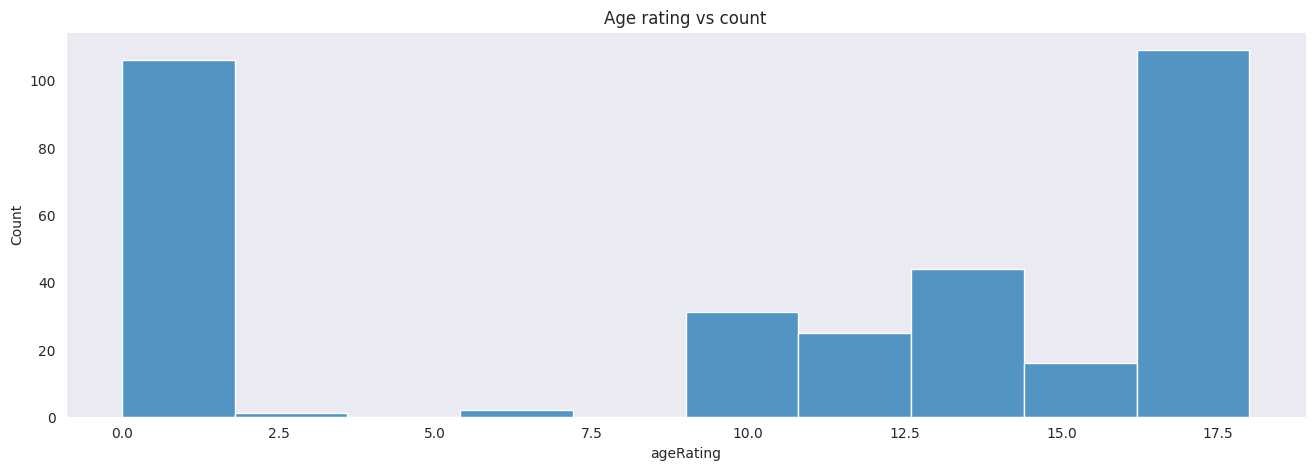

In [258]:
# lets focus on checking the  count of age rating
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

# hist graph vs count
sns.histplot( x= 'ageRating' , data = movies_df)

plt.title("Age rating vs count")



Text(0.5, 1.0, 'Age rating vs count')

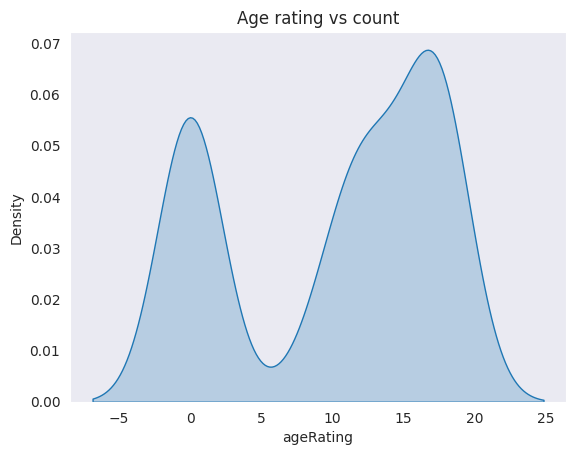

In [259]:
# kde plot
sns.kdeplot(x= "ageRating" , data = movies_df , fill = True)
plt.title("Age rating vs count")

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

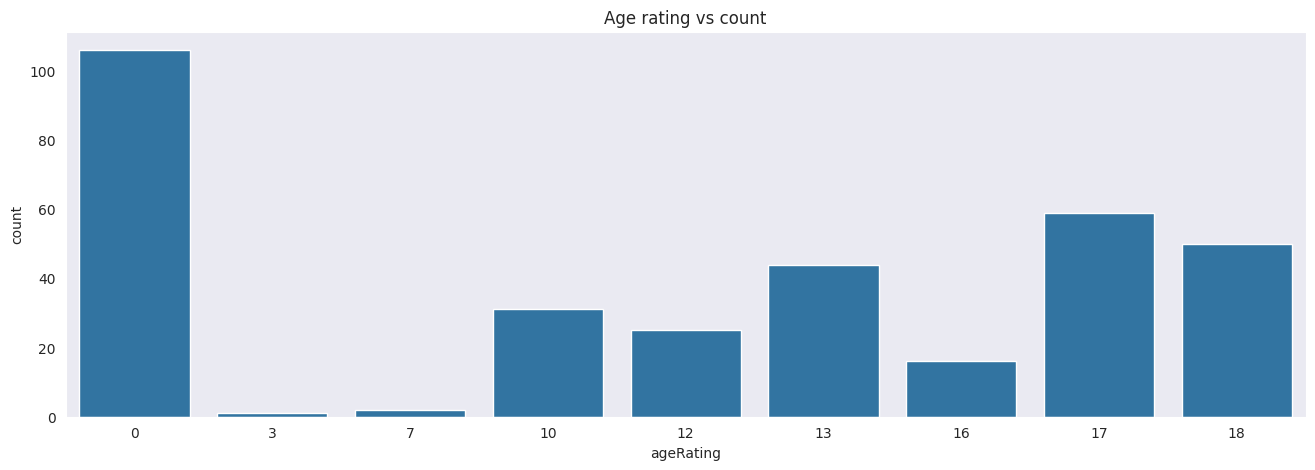

In [260]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = movies_df)

we come to come to know that a lot of the movies are above 17+  , we have some at 12+ , but below that the number is quite low and the once marked as 0 are actually unrated and will be later filtered out before training the model .

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

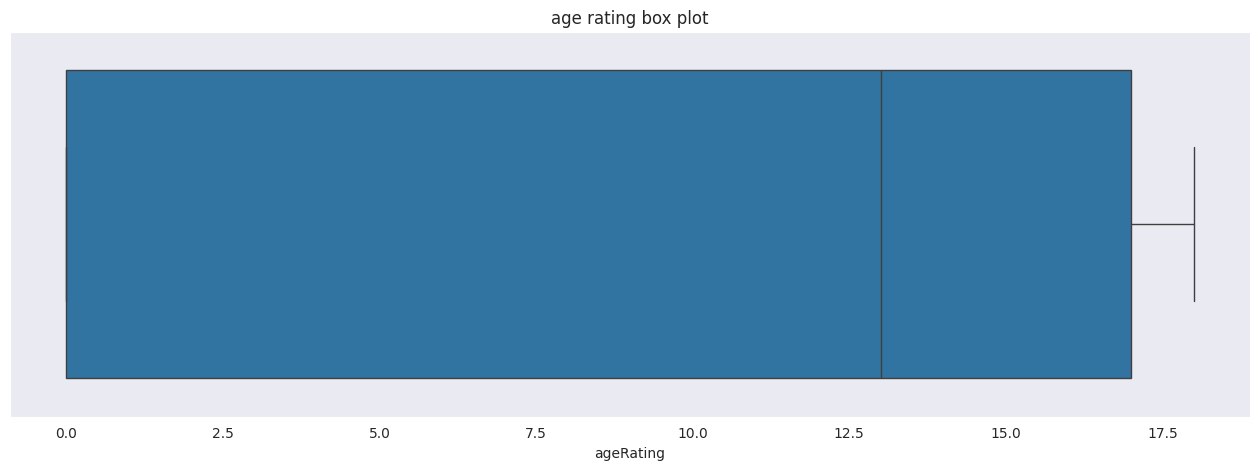

In [261]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=movies_df["ageRating"])

There are no dots outside the whiskers, which means all ageRating values are within the "expected" range .

median is towards the right as observed from the previous plots as well.

The wide box suggests a diverse set of age ratings in your movie data


#### Average rating

Text(0.5, 1.0, 'Average rating vs count')

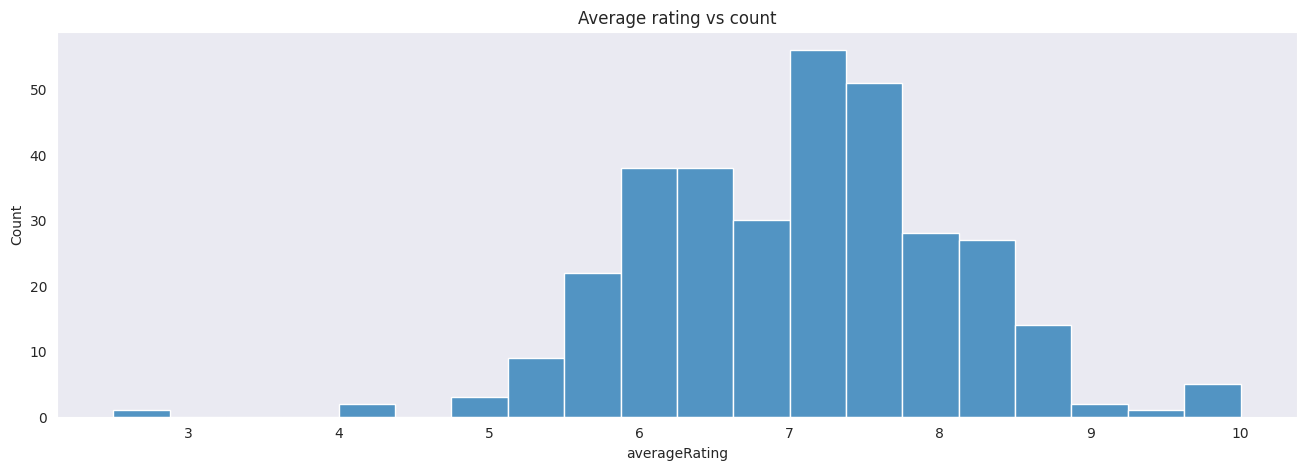

In [262]:
# lets focus on count vs the plot of average rating
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

sns.histplot( x = "averageRating" , data = movies_df)
plt.title("Average rating vs count")

<Axes: title={'center': 'distribution plots for average rating'}, xlabel='averageRating', ylabel='Density'>

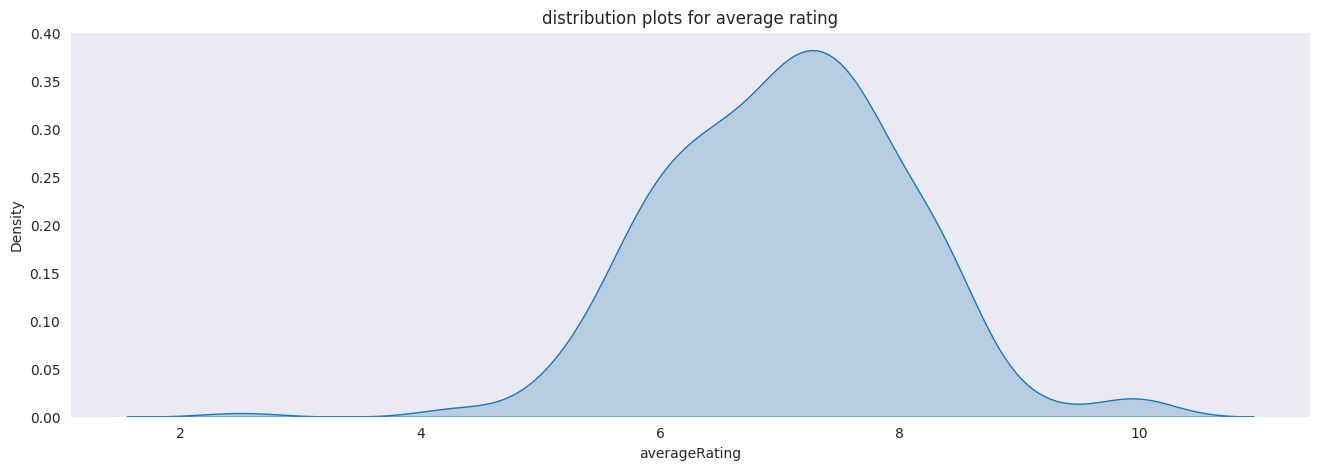

In [263]:
# lest also get the kde
plt.figure(figsize=(16 , 5));

plt.title("distribution plots for average rating")

sns.kdeplot( x = "averageRating", data = movies_df , fill = True)



from this we come to know that magority of the data have rating of 6 to 9   , as for 0 rating are same as unrated and to be removed from the model training .

Lets plot the created at with a ked plot it can be also give important relationship in case similar moves are added at the same time , or newer once are aded at same time .

<Axes: title={'center': 'average rating box plot'}, xlabel='averageRating'>

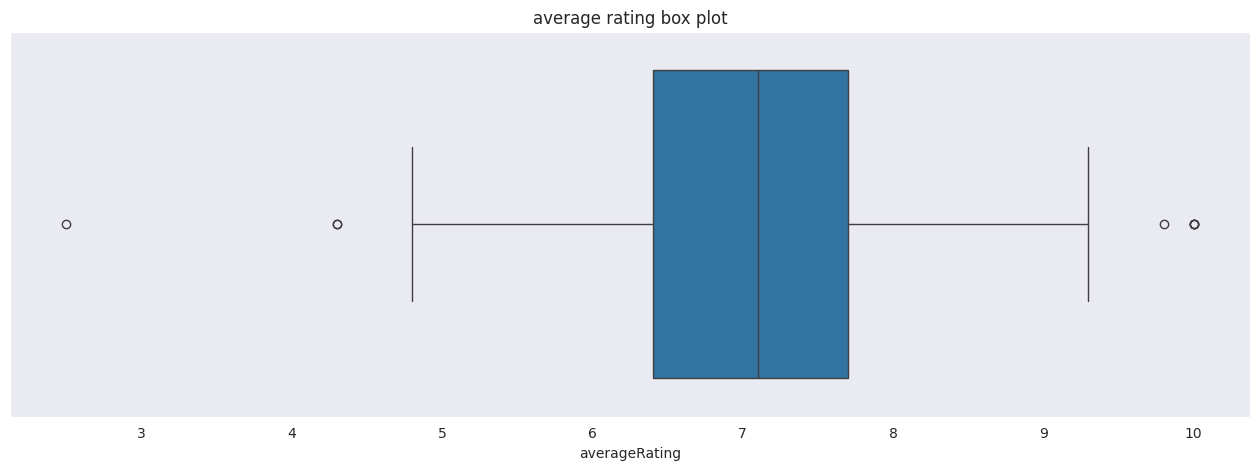

In [264]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("average rating box plot")
sns.boxplot(x=movies_df["averageRating"])

#### created at

<Axes: title={'center': 'created at vs count'}, xlabel='createdAt', ylabel='Count'>

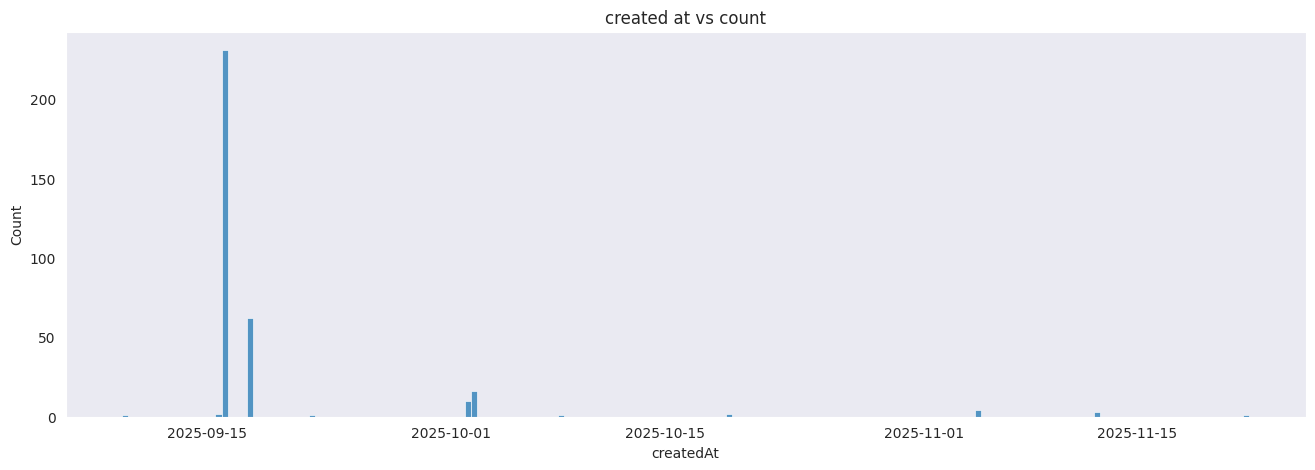

In [265]:
# hist graph of count vs created at time
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("created at vs count")
sns.histplot( x = "createdAt" , data = movies_df)

Text(0.5, 1.0, 'created at vs count')

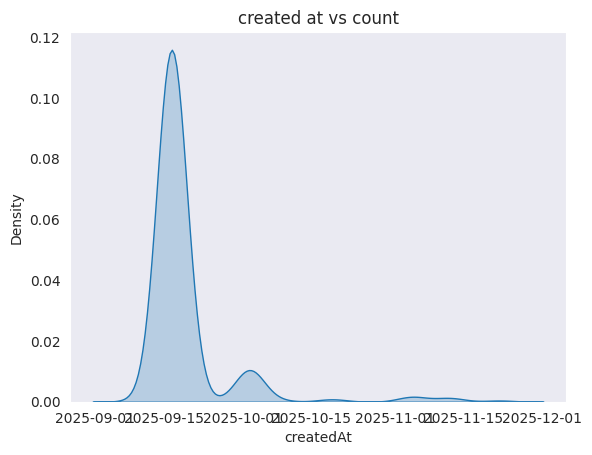

In [266]:
# create a kde chat
sns.kdeplot(x = "createdAt" , data = movies_df , fill = True)
plt.title("created at vs count")


most of the data is added at a peak time of 2025/9/15 then its reduced constant with small additions.

Lets plot a distrubution graphs for release date

#### Release date

<Axes: title={'center': 'release date  vs count'}, xlabel='releaseDate', ylabel='Count'>

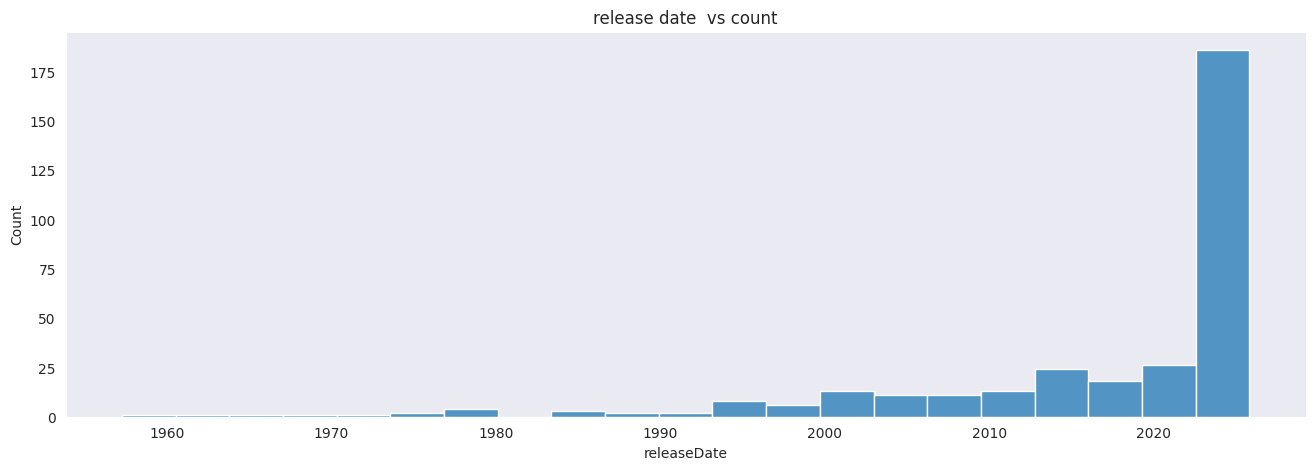

In [267]:
# hist graph for release date vs count
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("release date  vs count")
sns.histplot( x = "releaseDate" , data = movies_df)


Text(0.5, 1.0, 'release date  vs count')

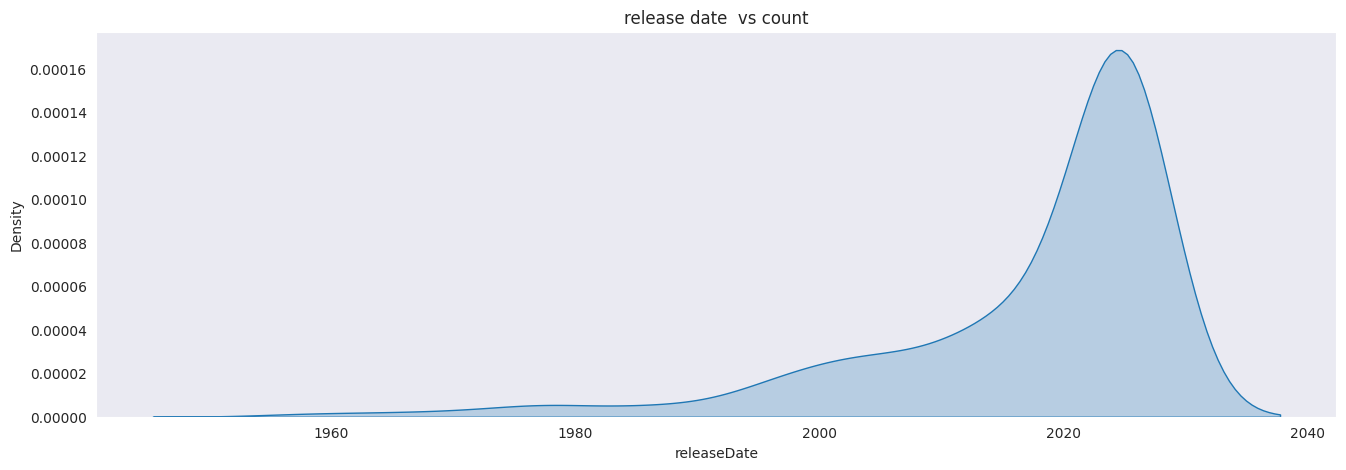

In [268]:
#kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "releaseDate" , data = movies_df , fill = True)
plt.title("release date  vs count")

most of the movies are in the range of 2020 - 2025

<Axes: title={'center': 'release box plot'}, xlabel='releaseDate'>

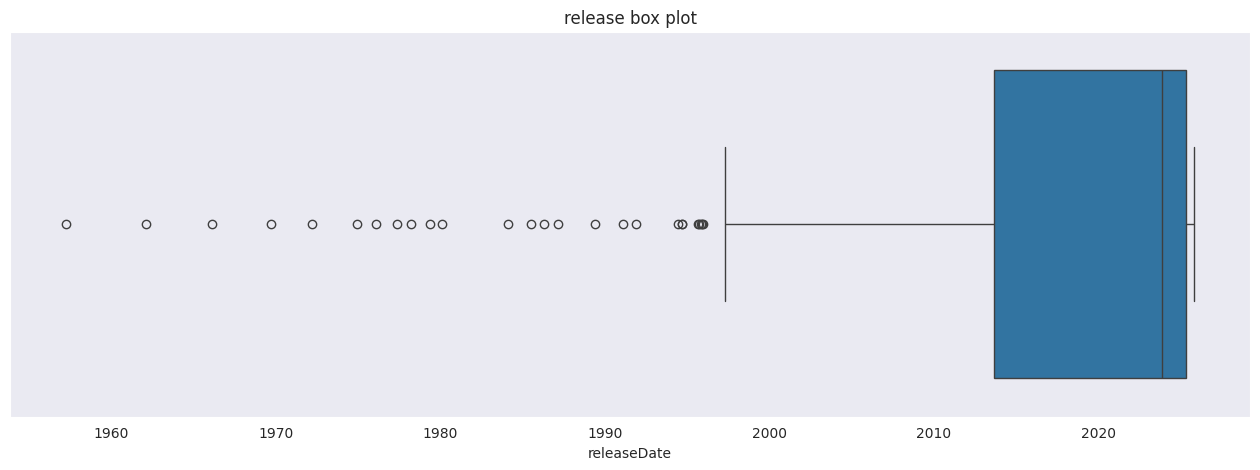

In [269]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("release box plot")
sns.boxplot(x=movies_df["releaseDate"])

#### Run time

<Axes: title={'center': 'Runtime vs count'}, xlabel='runTime', ylabel='Count'>

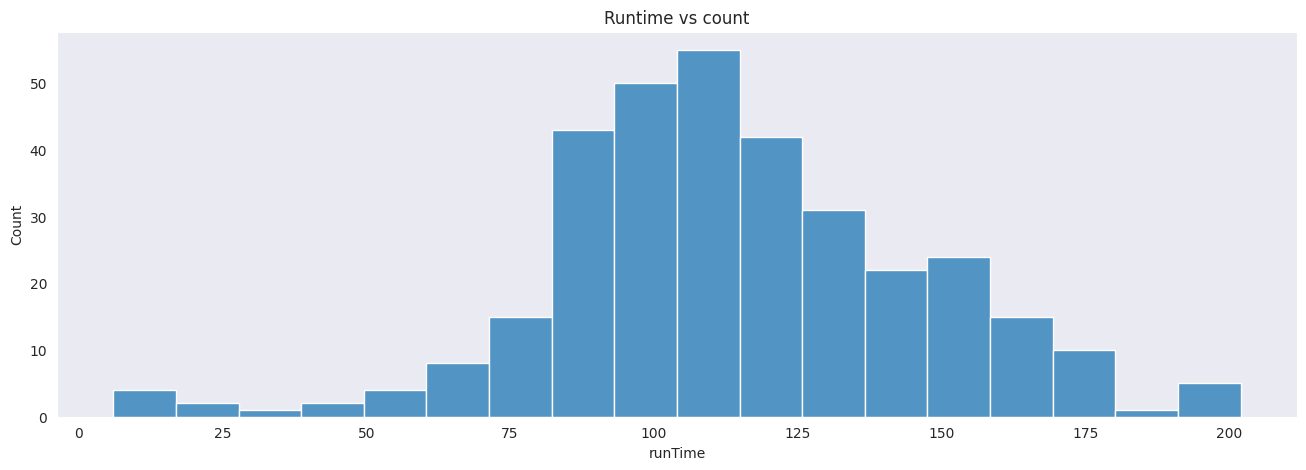

In [270]:
#now lets check the distribution of runtime

plt.figure(figsize= (16, 5));
plt.title("Runtime vs count")

# lets have a histplot first
sns.histplot(x = "runTime", data = movies_df)

<Axes: title={'center': 'Runtime vs count'}, xlabel='runTime', ylabel='Density'>

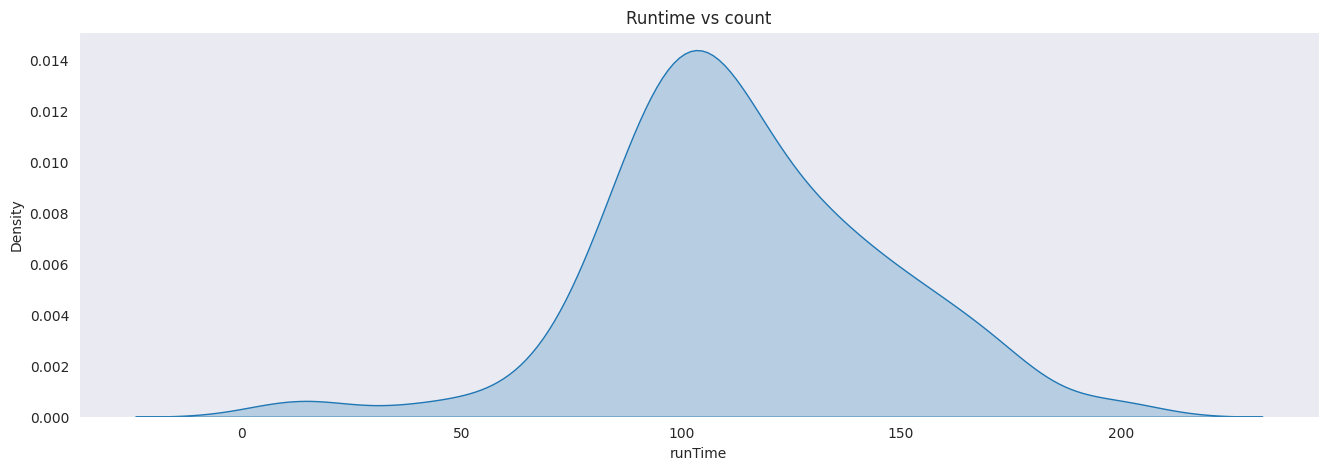

In [271]:
plt.figure(figsize= (16, 5));
plt.title("Runtime vs count")

# lets have a kde plot
sns.kdeplot(x = "runTime", data = movies_df , fill = True)

This is as expected mazority are at the range of 75 to 150

<Axes: title={'center': 'run time box plot'}, xlabel='runTime'>

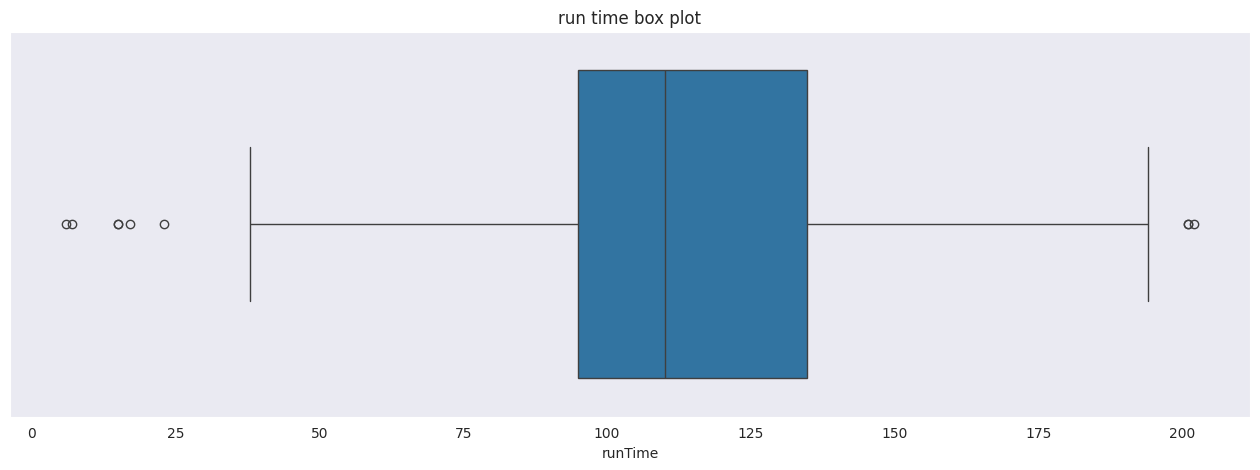

In [272]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("run time box plot")
sns.boxplot(x=movies_df["runTime"])

### **Categorical Feature Analysis**

In [273]:
#lets compare movie count by genere
movies_analysis =  movies_df.copy() # create a copy

# Replace missing or empty genre lists with a placeholder
movies_analysis['genre_filled'] = movies_analysis['genre'].apply(lambda x: x if isinstance(x, list) and len(x) > 0 else ['Unknown'])

# Explode and count including the placeholder
exploded_genres = movies_analysis['genre_filled'].explode()
genre_counts = exploded_genres.value_counts()
# lets check the count
genre_counts



,count
genre_filled,
Action,121
Drama,108
Adventure,94
Thriller,82
Comedy,75
Science Fiction,63
Romance,58
Fantasy,52
Horror,47


In [274]:
# lets convertthis to a df
genre_df = genre_counts.reset_index()
genre_df.columns = ['Genre', 'Count']

genre_df

,Genre,Count
0,Action,121
1,Drama,108
2,Adventure,94
3,Thriller,82
4,Comedy,75
5,Science Fiction,63
6,Romance,58
7,Fantasy,52
8,Horror,47
9,Animation,47


<Axes: title={'center': 'Genre Counts in Movies data set'}, xlabel='Count', ylabel='Genre'>

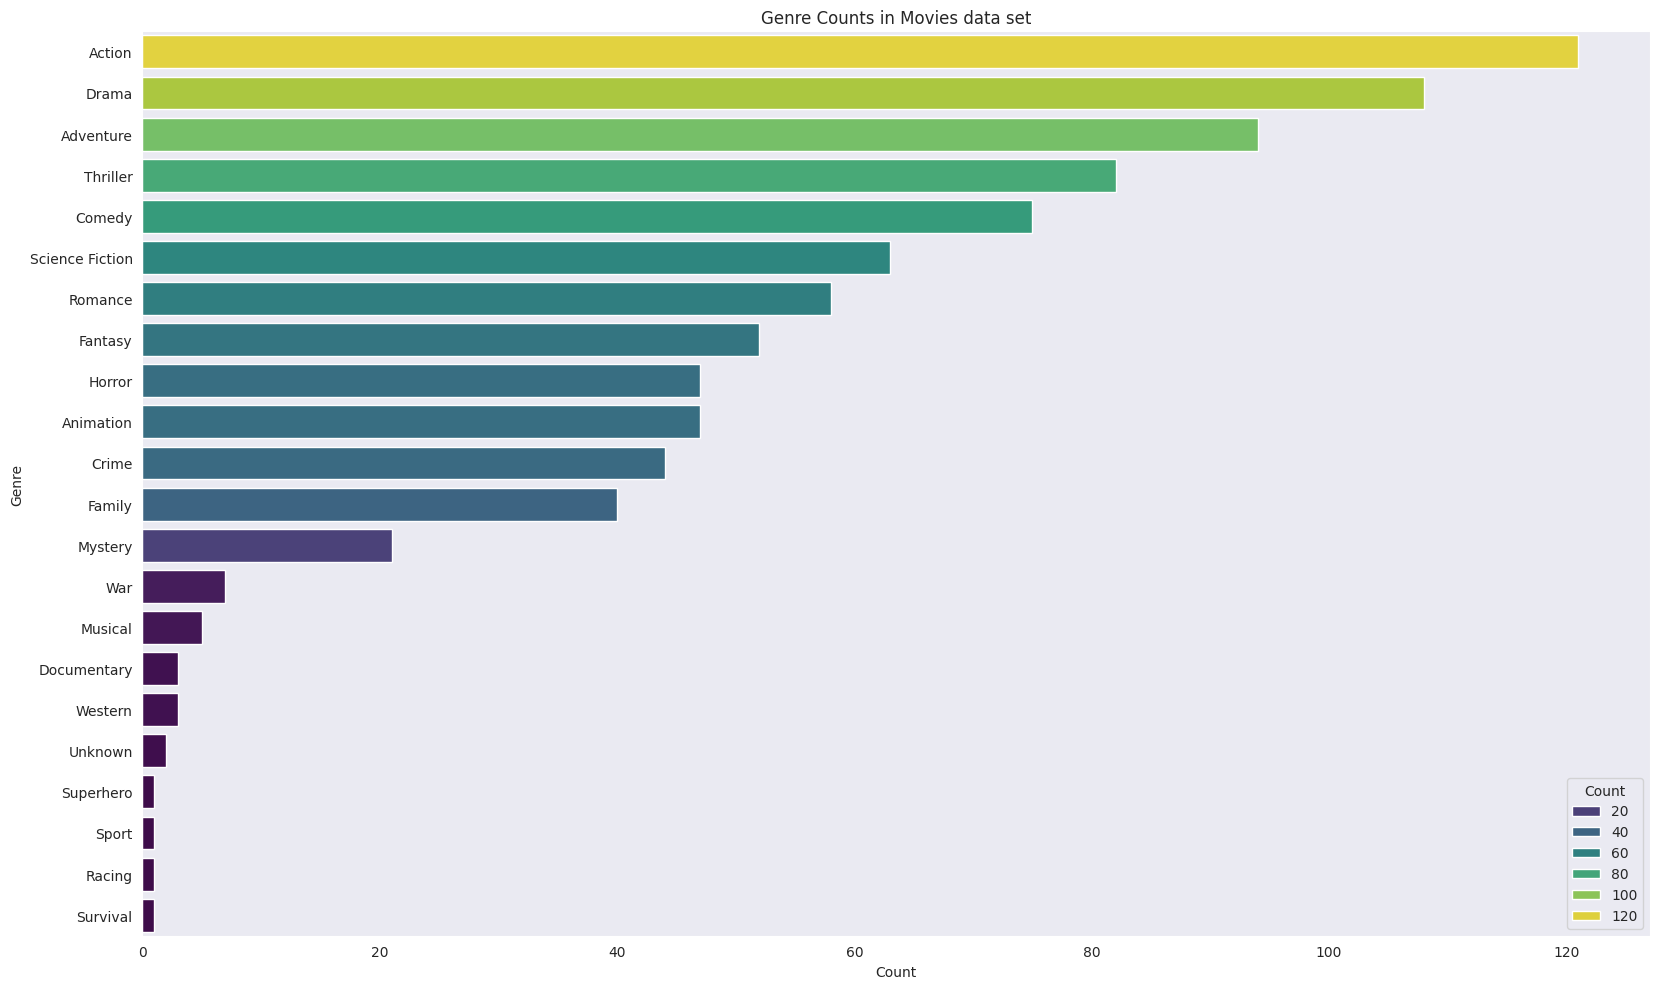

In [275]:
# lets plot the geners to see the distribution
sns.set_style("dark")
plt.figure(figsize=(16, 10));
plt.title('Genre Counts in Movies data set')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
sns.barplot(x='Count', y='Genre', data=genre_df, palette='viridis' , hue="Count")


observation here we can see the distribution of genere currently action is quite hight .

<Axes: title={'center': 'Tag Counts in Movies data set top 15'}, xlabel='Count', ylabel='Tags'>

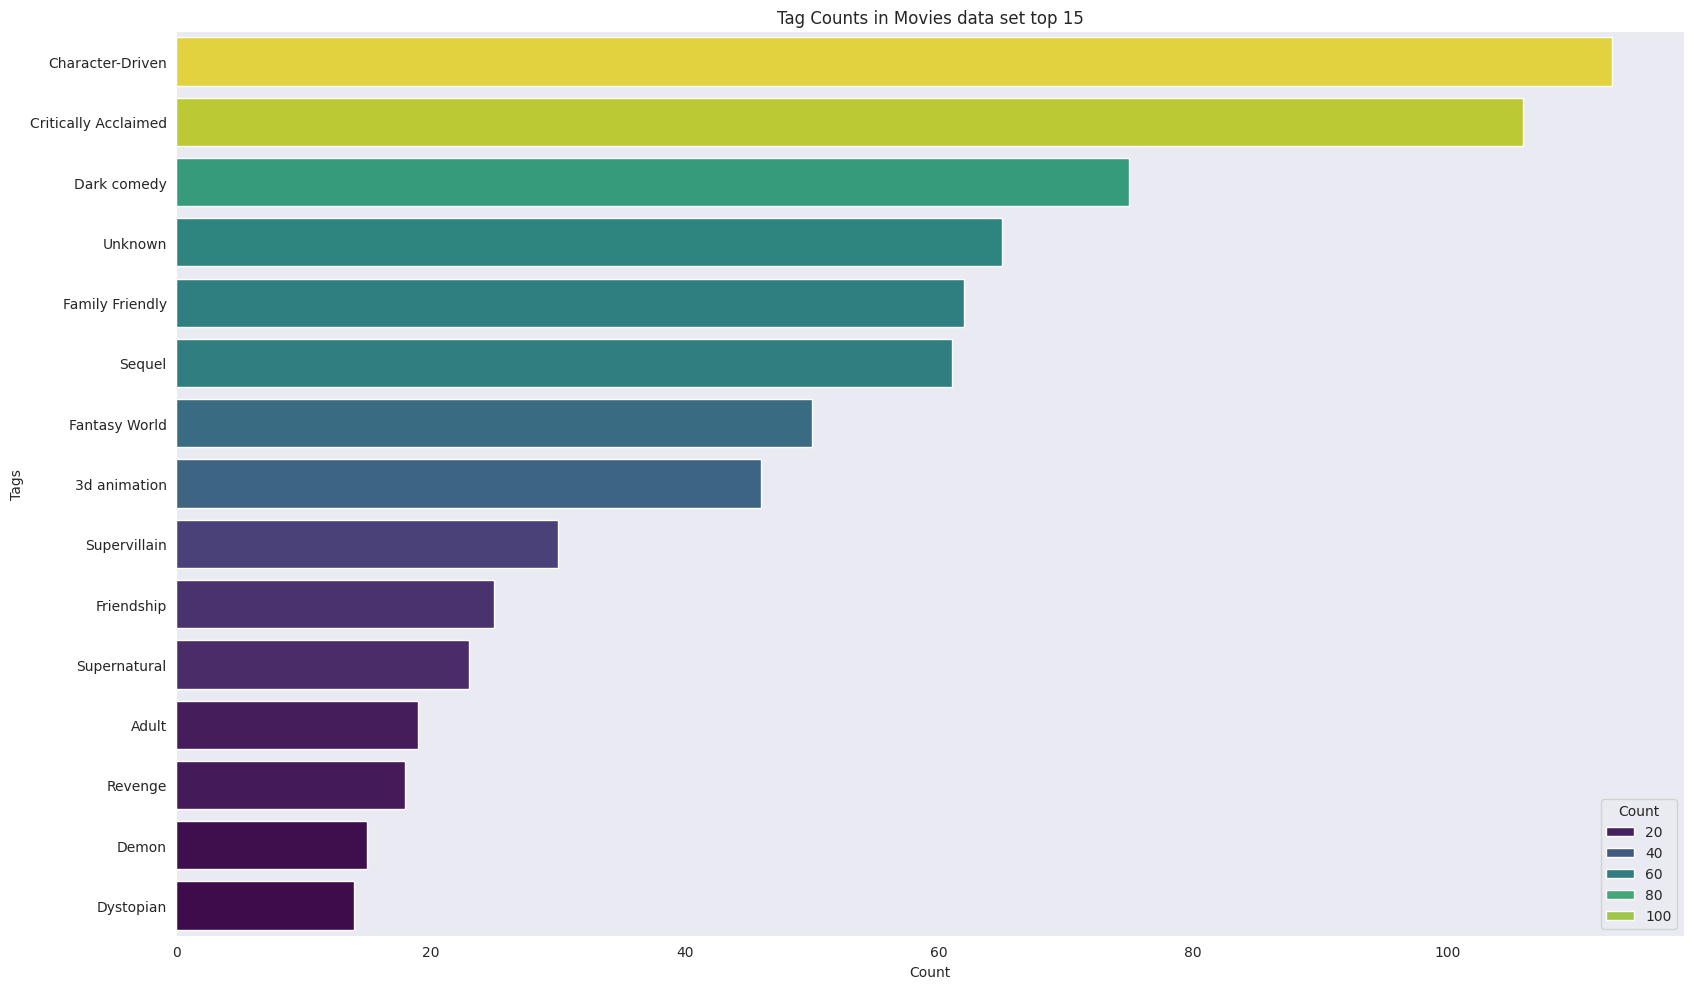

In [276]:
# lets do the same for tags
# replace epty with Unknown
movies_analysis["tags_filled"] = movies_analysis["tags"].apply(lambda x : x if isinstance(x , list) and len(x) > 0 else ["Unknown"])

# explore the tags
exploded_tags = movies_analysis["tags_filled"].explode()
tags_count = exploded_tags.value_counts()

# convert to df
tags_df = tags_count.reset_index()
tags_df.columns = ['Tag', 'Count']

# lets plot the tags to see the distribution
sns.set_style("dark")
plt.figure(figsize=(16, 10));
plt.title('Tag Counts in Movies data set top 15')
plt.xlabel('Count')
plt.ylabel('Tags')
plt.tight_layout()
sns.barplot(x='Count', y='Tag', data=tags_df.head(15), palette='viridis' , hue="Count")

we get a clear picture from this abouve plot the distribution of tags

<Axes: xlabel='isActive', ylabel='count'>

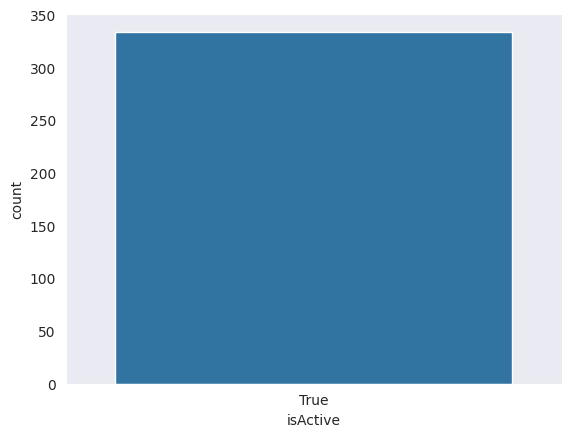

In [277]:
# lets also have a check on the distribution of active and non active
sns.countplot(x= "isActive" , data = movies_df )

from current observation all the movies are active , we probebly dont really want to tarin on inactive movies as well . so any inactive movies will be excluded from training later .

In [278]:
# now lets analize some relation like what per sent of average ratings is given by tags
exploded_genre_rating =  movies_analysis.explode("genre")

# lets drop any missing values
exploded_genre_rating = exploded_genre_rating.dropna(subset= ["genre" , "averageRating"])

# group by genere : calculate the count and mean of average rating
genre_stats = exploded_genre_rating.groupby("genre").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

genre_stats



,genre,Count,AvgRating
0,Action,119,7.103361
1,Adventure,94,7.390426
2,Animation,46,7.726087
3,Comedy,75,7.030667
4,Crime,43,7.218605
5,Documentary,3,6.600000
6,Drama,105,7.093333
7,Family,40,7.560000
8,Fantasy,52,7.380769
9,Horror,46,6.508696


In [279]:
# lets sort by count
genre_stats = genre_stats.sort_values("Count" , ascending=False)
genre_stats.head()

,genre,Count,AvgRating
0,Action,119,7.103361
6,Drama,105,7.093333
1,Adventure,94,7.390426
18,Thriller,79,7.002532
3,Comedy,75,7.030667


<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

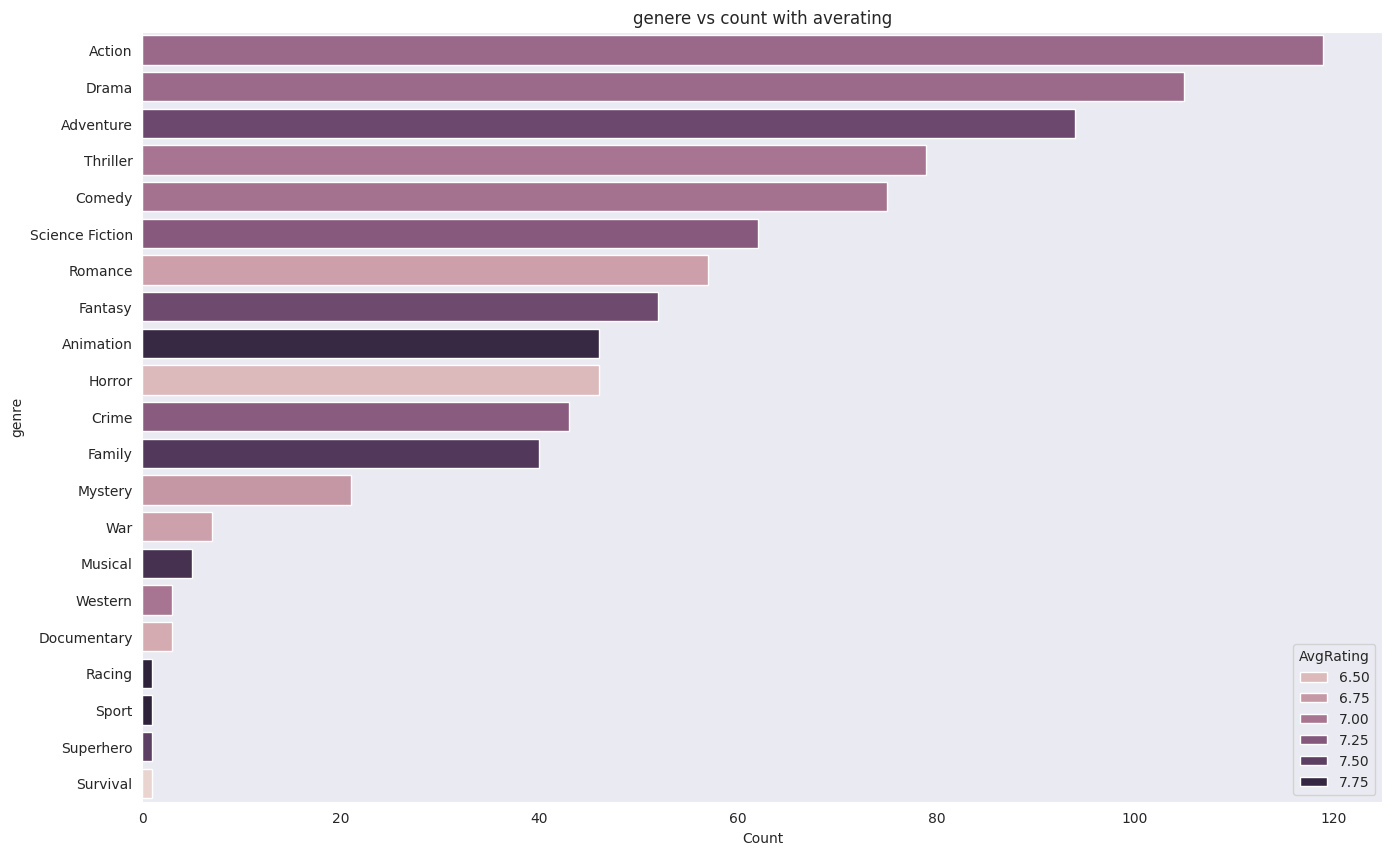

In [280]:
# lets plot the graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

from this we can crealy observe the darkest color genere which is highly rating .

/tmp/ipython-input-1961179228.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


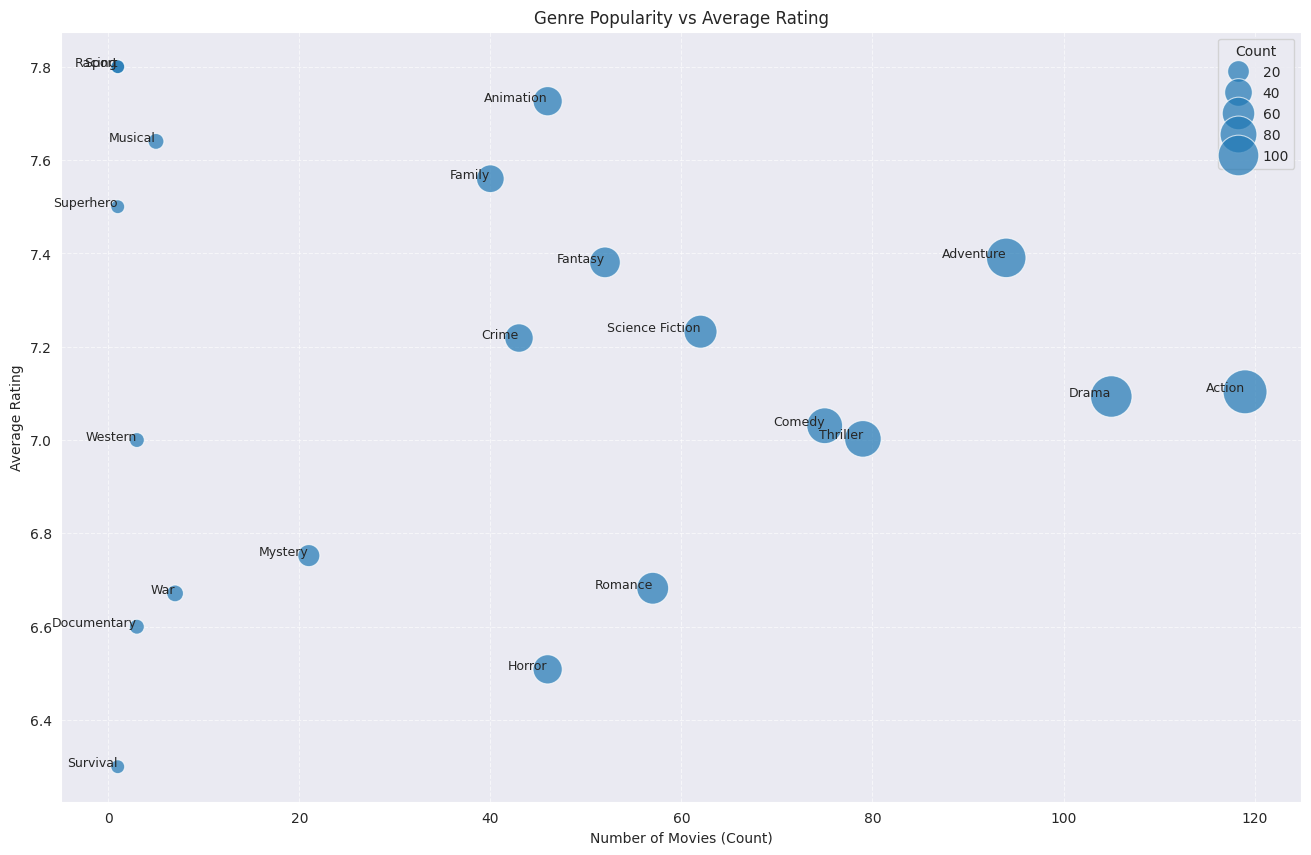

In [281]:
# let get a scatter plot for better visulization
plt.figure(figsize=(16, 10));
sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with genre names for better readability
for i, row in genre_stats.iterrows():
    plt.text(row['Count'], row['AvgRating'], row['genre'], fontsize=9, ha='right')

plt.title('Genre Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-2520787598.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


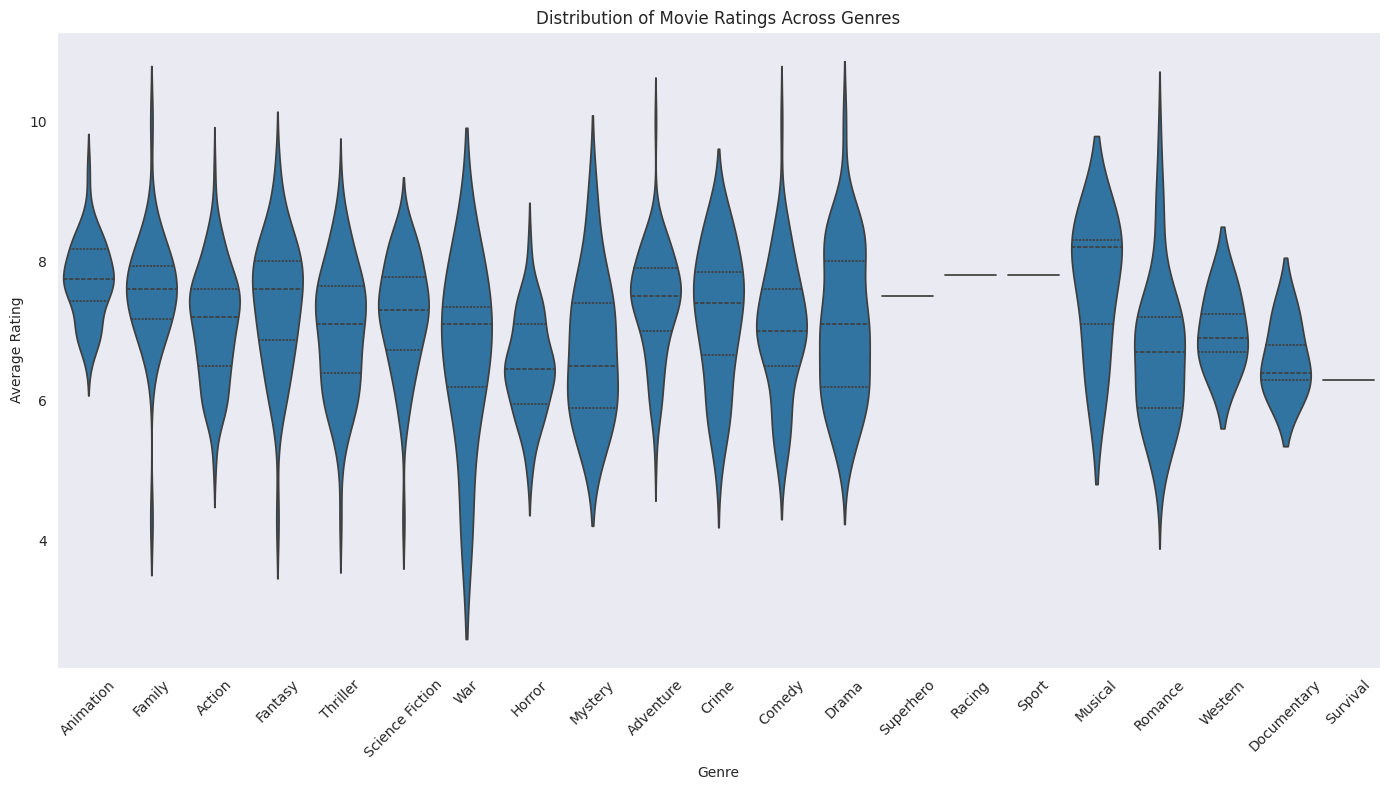

In [282]:
#lets also try a voilene plot
plt.figure(figsize=(14, 8))
sns.violinplot(
    x='genre',
    y='averageRating',
    data=exploded_genre_rating,
    inner='quartile',
    scale='width',
)

plt.xticks(rotation=45)
plt.title('Distribution of Movie Ratings Across Genres')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

In [283]:
# lets also visulaize tags for bettr undersatnding
exploded_tags_rating =  movies_analysis.explode("tags")

# lets drop any missing values
exploded_tags_rating = exploded_tags_rating.dropna(subset= ["tags" , "averageRating"])

# group by tags : calculate the count and mean of average rating
tag_stats = exploded_tags_rating.groupby("tags").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

tag_stats

,tags,Count,AvgRating
0,3d animation,44,7.727273
1,Adult,19,7.300000
2,Aggressive,10,7.490000
3,Antagonistic,4,7.725000
4,Artificial intelligence,10,7.430000
...,...,...,...
74,Trance,2,7.050000
75,Violent,3,6.333333
76,Warrior,4,7.300000
77,Wedding,4,6.750000


In [284]:
# lets sort by count
tag_stats.sort_values("Count" , ascending=False)

,tags,Count,AvgRating
11,Character-Driven,112,7.459821
16,Critically Acclaimed,106,8.131132
21,Dark comedy,75,7.037333
27,Family Friendly,61,7.596721
59,Sequel,60,7.173333
...,...,...,...
28,Fandom,1,8.300000
61,Slow Burn,1,8.300000
58,Save the world,1,8.300000
50,Privacy,1,4.300000


<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

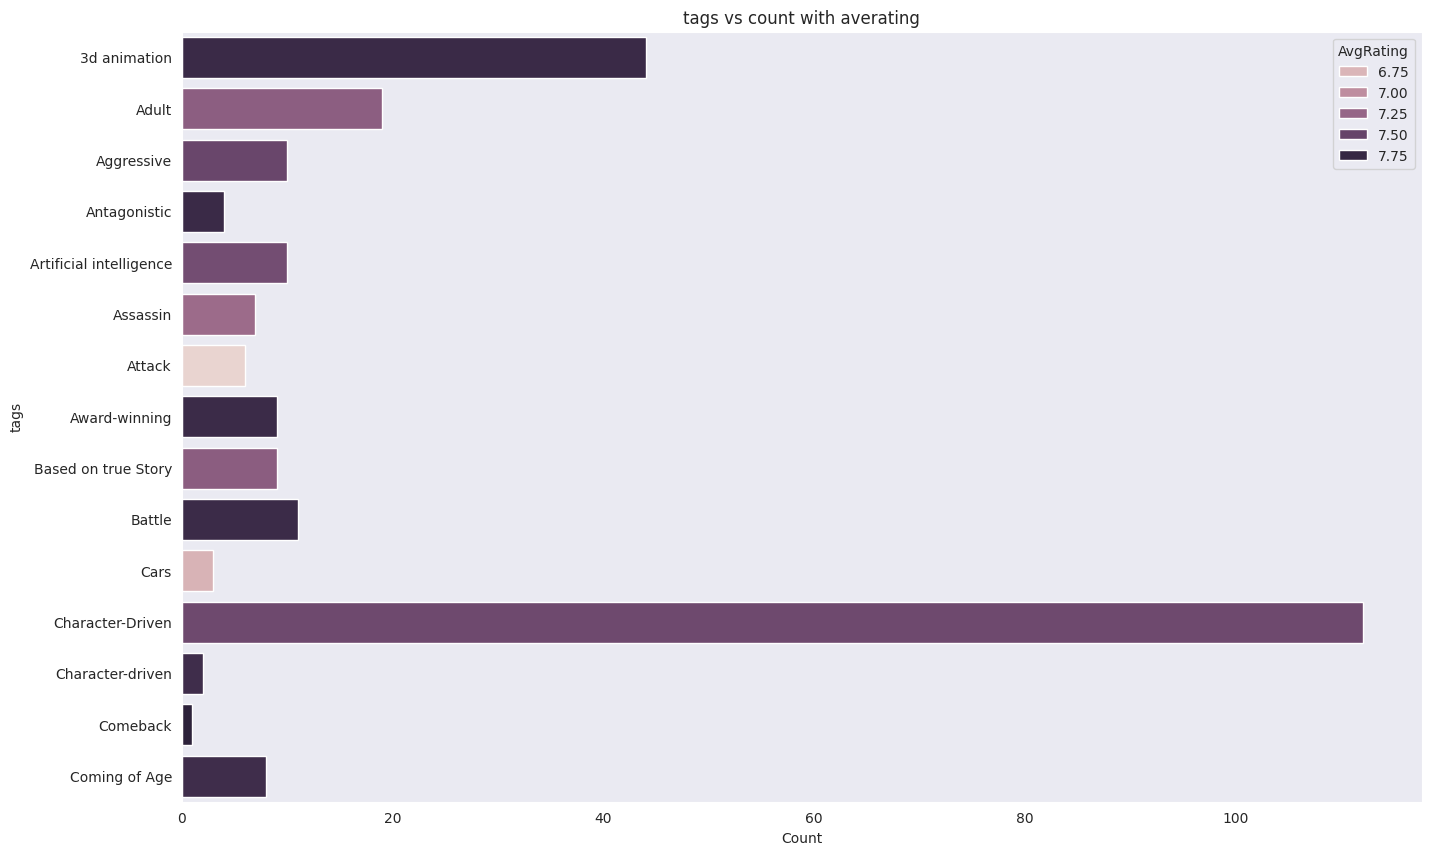

In [285]:
# lets plot the graph lets only take top 15
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tag_stats.head(15) , hue= "AvgRating")

/tmp/ipython-input-3240491434.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = tag_stats.head(15) , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


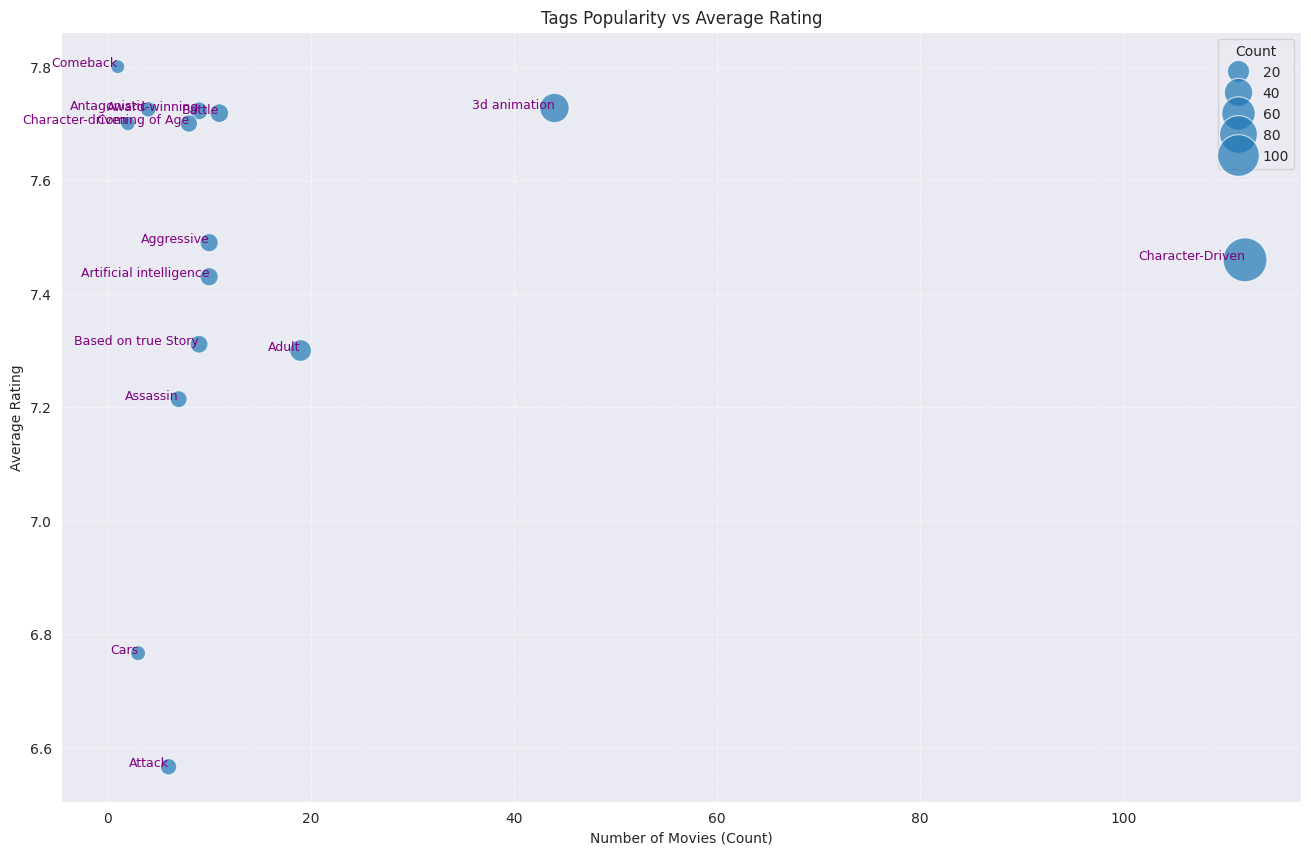

In [286]:
# let get a scatter plot for better visulization lets only take top 15
plt.figure(figsize=(16, 10));
sns.scatterplot(data = tag_stats.head(15) , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with tags names for better readability
for i, row in tag_stats.head(15).iterrows():
    plt.text(row['Count'], row['AvgRating'], row['tags'], fontsize=9, ha='right' , color="purple")

plt.title('Tags Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

                       tags  Count  AvgRating
0              3d animation     44   7.727273
1                     Adult     19   7.300000
2                Aggressive     10   7.490000
3              Antagonistic      4   7.725000
4   Artificial intelligence     10   7.430000
..                      ...    ...        ...
74                   Trance      2   7.050000
75                  Violent      3   6.333333
76                  Warrior      4   7.300000
77                  Wedding      4   6.750000
78               Witchcraft     12   7.516667

[79 rows x 3 columns]


<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

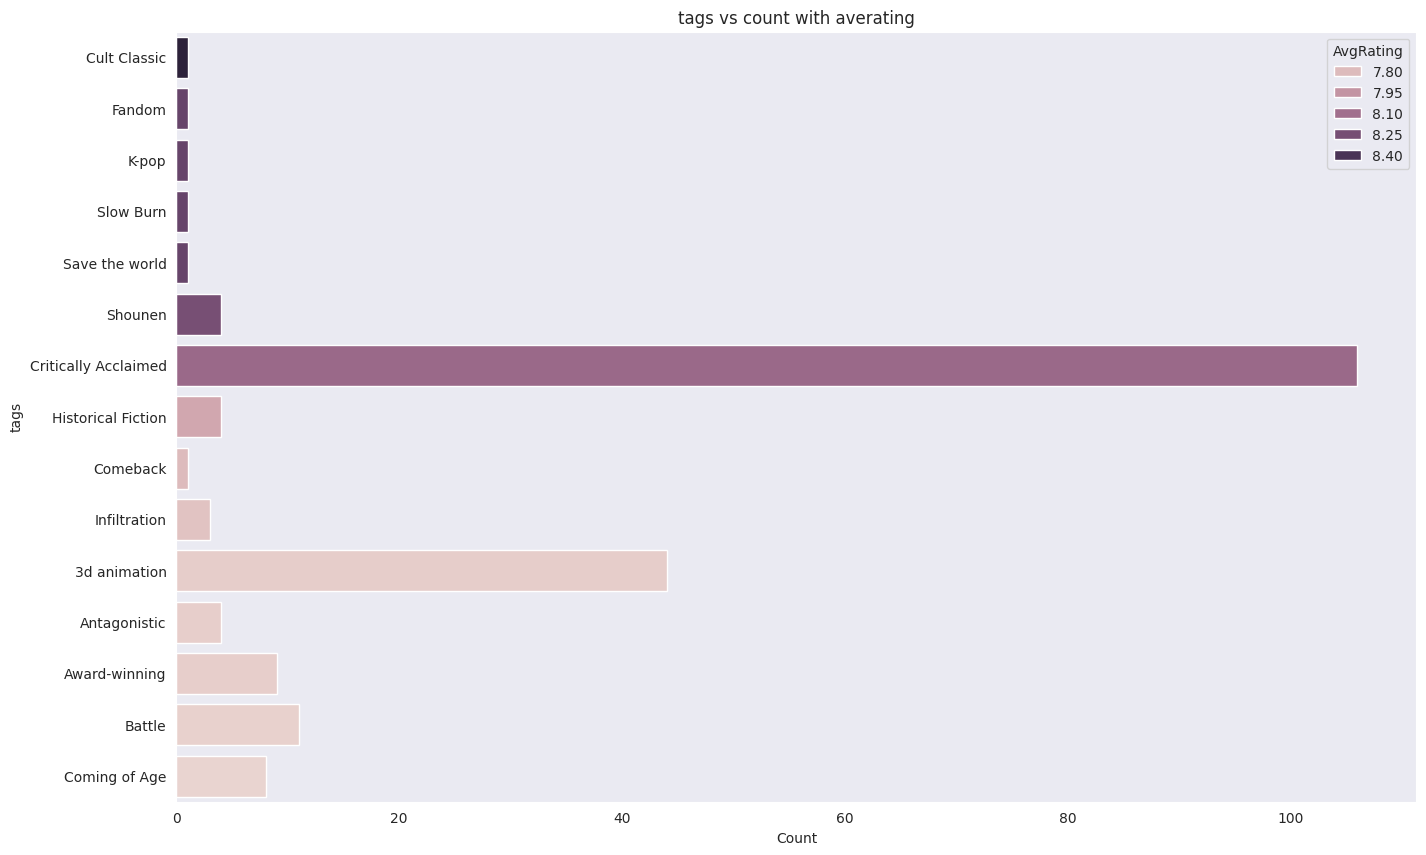

In [287]:
# lets also have plots with sorted by average rating
tag_stats_sort = tag_stats.sort_values("AvgRating" , ascending=False)
print(tag_stats)
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tag_stats_sort.head(15) , hue= "AvgRating")

                    tags  Count  AvgRating
11      Character-Driven    112   7.459821
16  Critically Acclaimed    106   8.131132
21           Dark comedy     75   7.037333
27       Family Friendly     61   7.596721
59                Sequel     60   7.173333
..                   ...    ...        ...
28                Fandom      1   8.300000
61             Slow Burn      1   8.300000
58        Save the world      1   8.300000
50               Privacy      1   4.300000
72                 Thief      1   5.800000

[79 rows x 3 columns]


<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

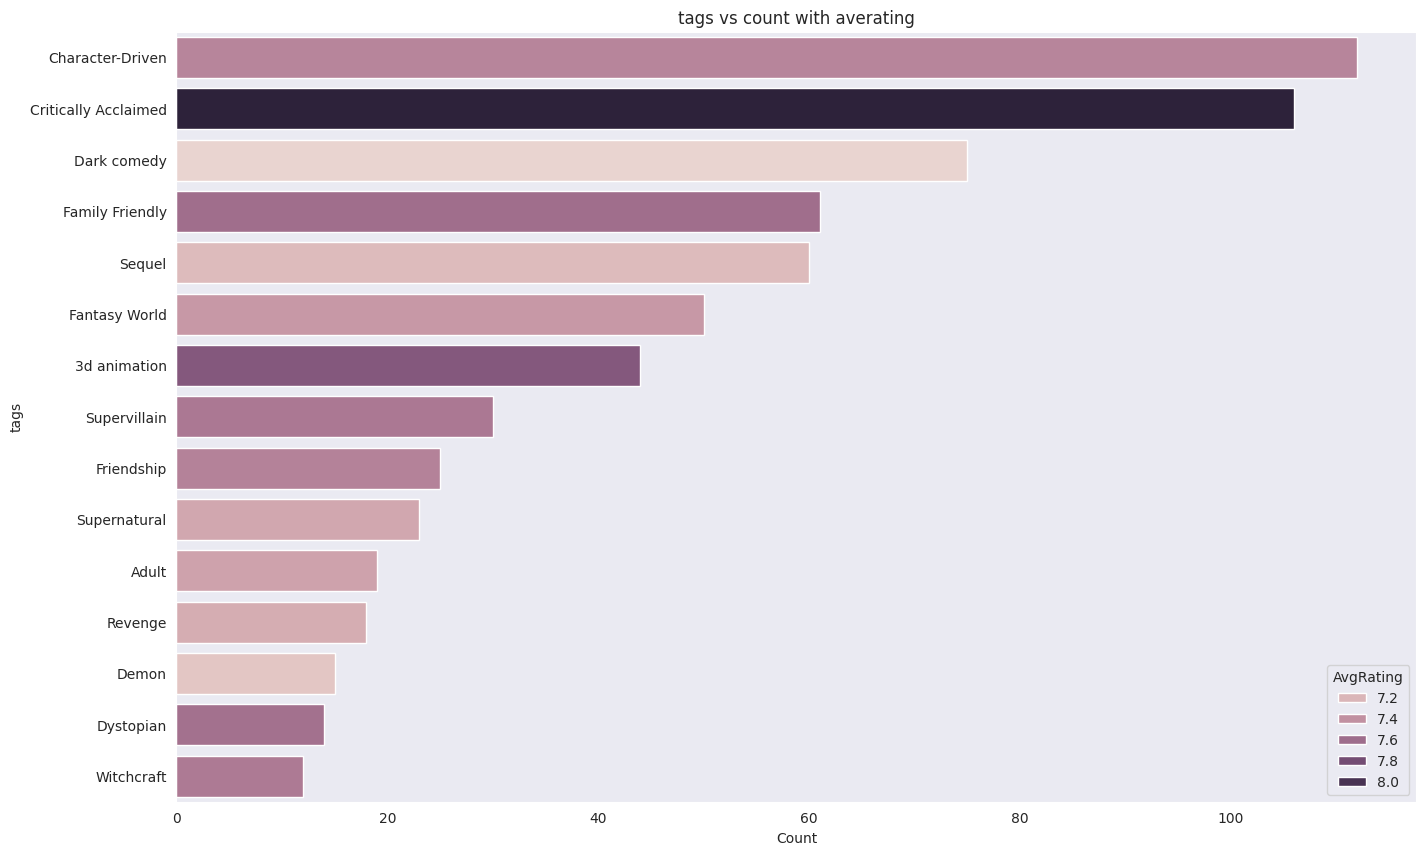

In [288]:
# lets also have plots with sorted by count
tag_stats_sort = tag_stats.sort_values("Count" , ascending=False)
print(tag_stats_sort)
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tag_stats_sort.head(15) , hue= "AvgRating")

/tmp/ipython-input-312118915.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


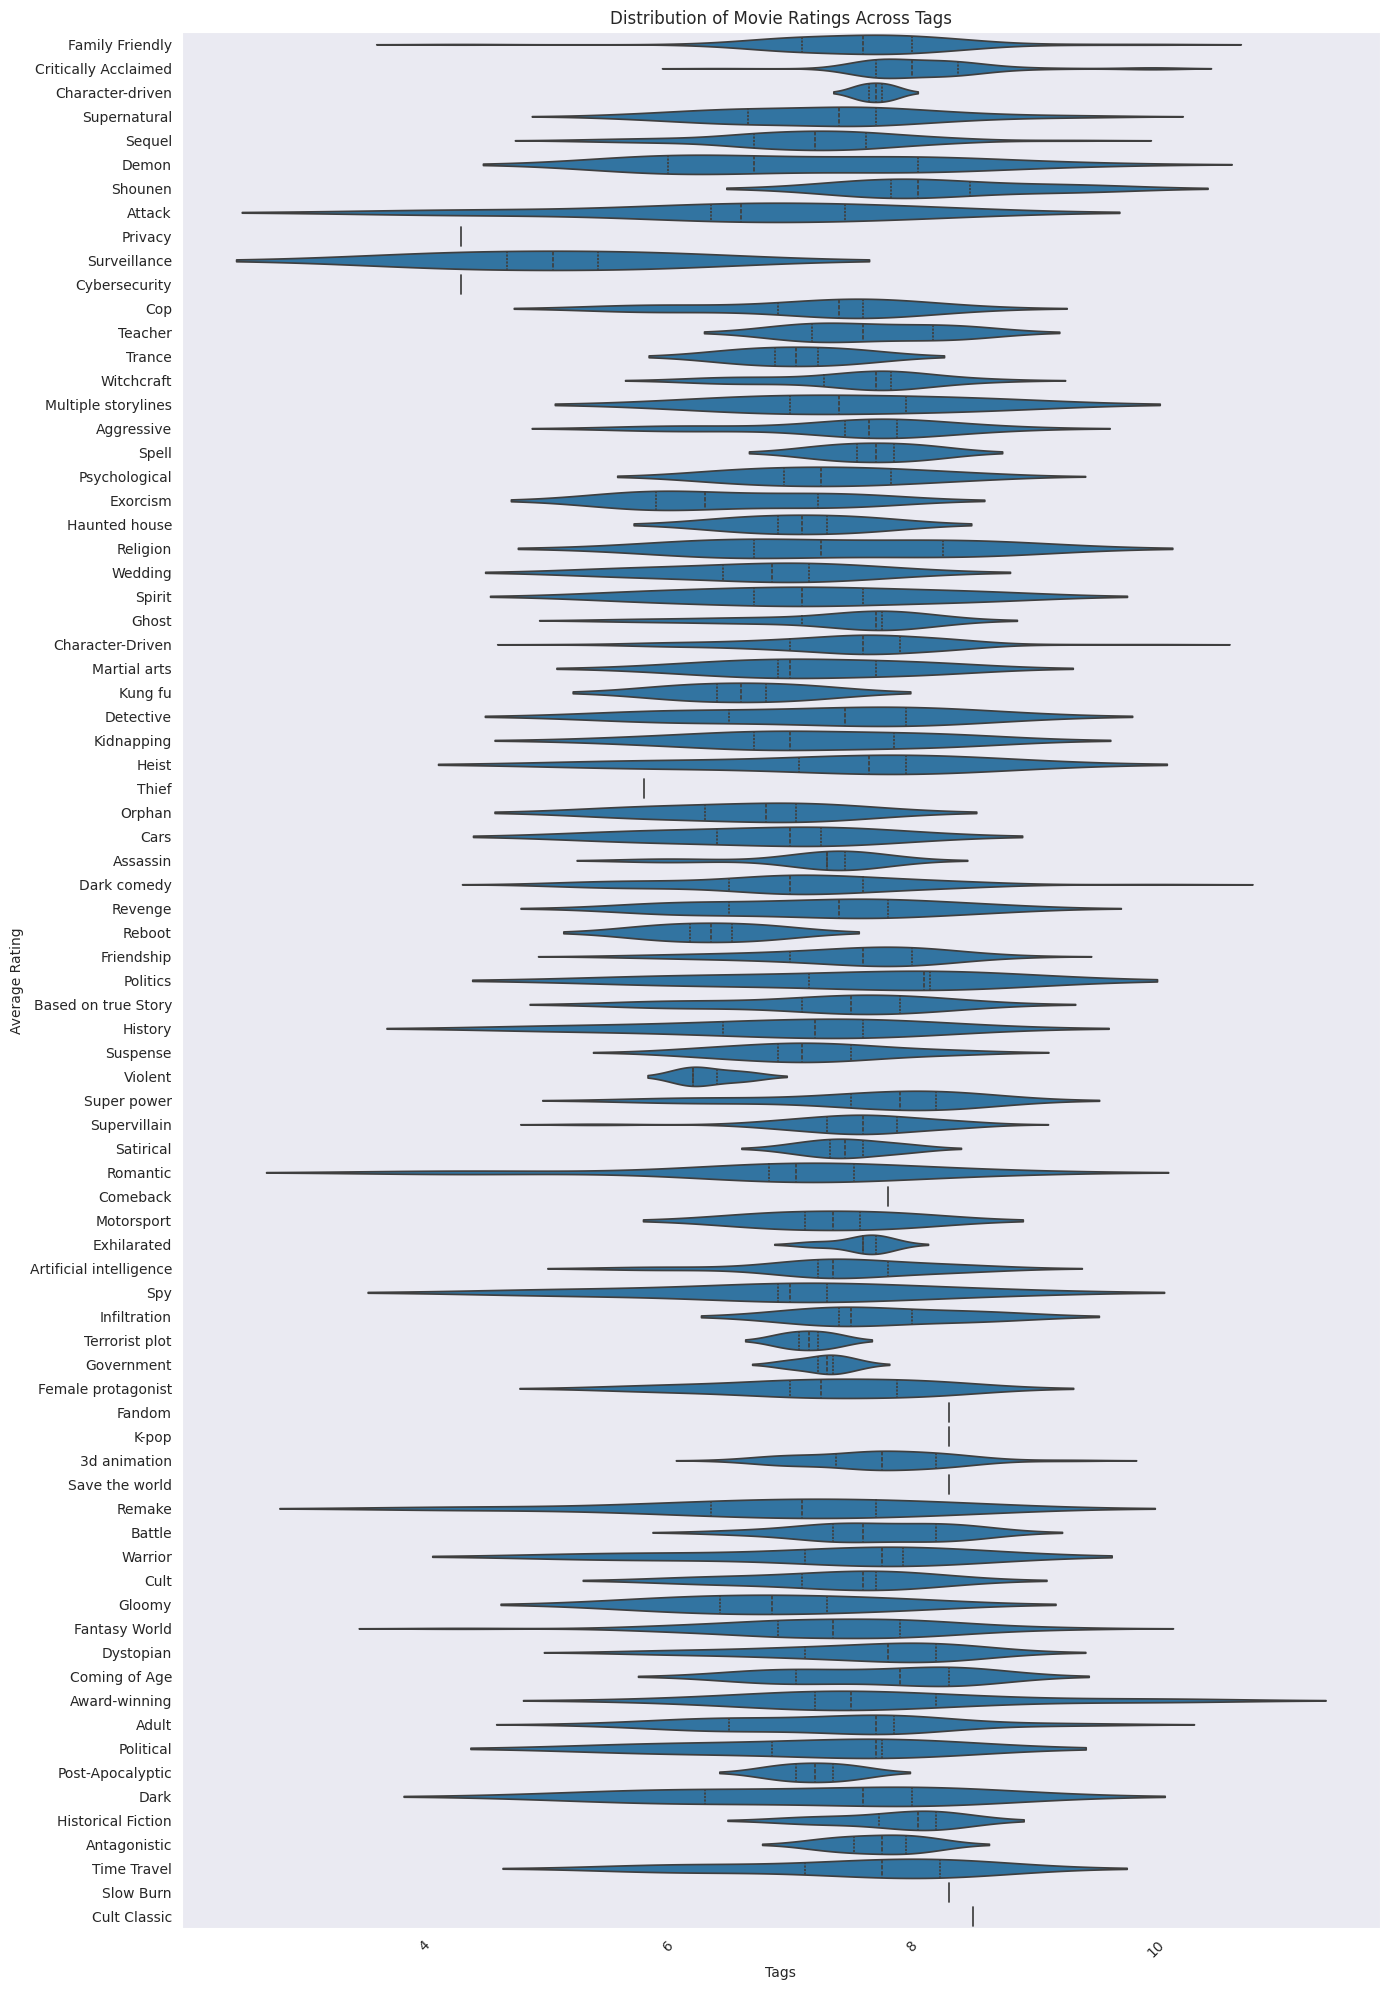

In [289]:
#lets also try a voilene plot
plt.figure(figsize=(14, 20))
sns.violinplot(
    y='tags',
    x='averageRating',
    data=exploded_tags_rating,
    inner='quartile',
    scale='width',
)

plt.xticks(rotation=45)
plt.title('Distribution of Movie Ratings Across Tags')
plt.xlabel('Tags')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

this shows all the destribution

/tmp/ipython-input-3398480054.py:15: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


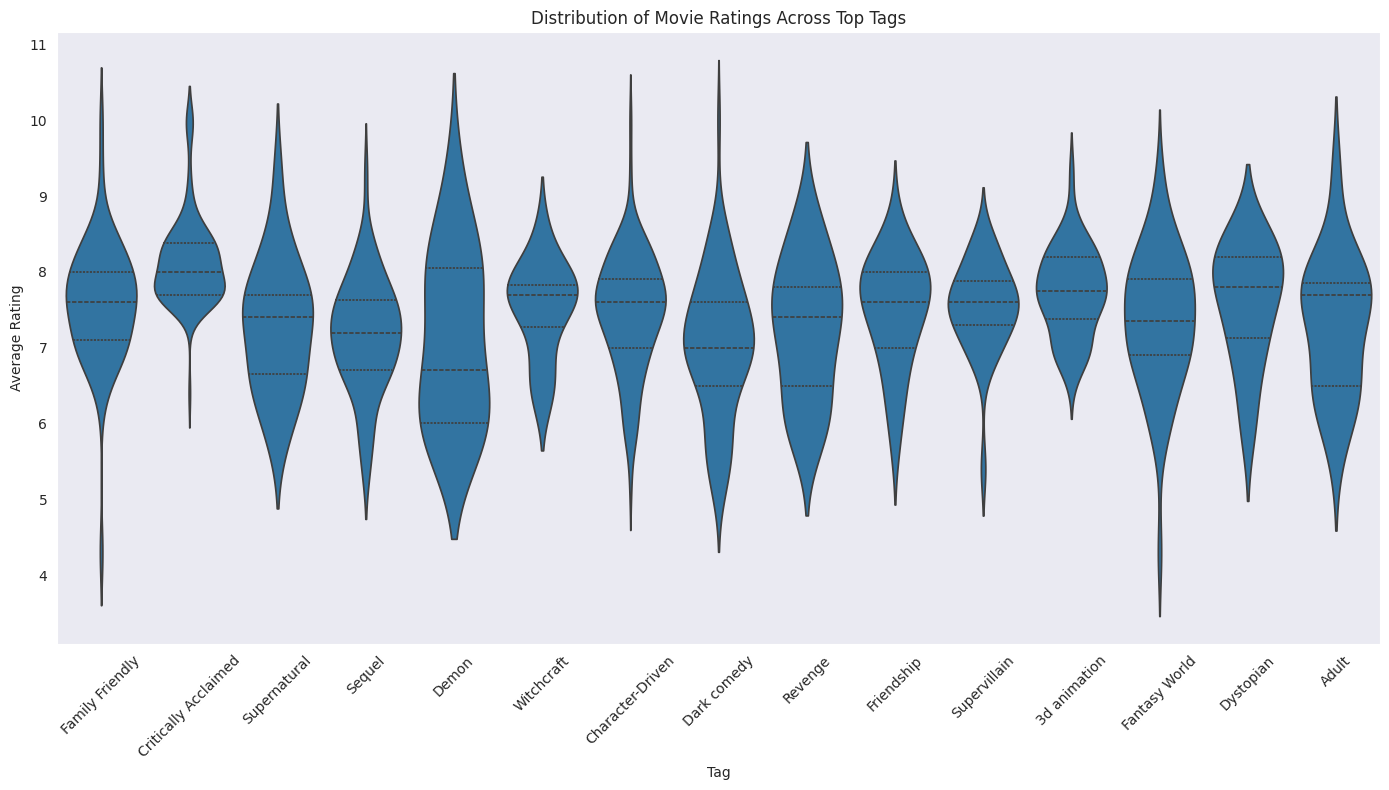

In [290]:
# lets have a minimized graph with 15 tags
top_n = 15
# Get top N tags by count
top_tags = (
    exploded_tags_rating['tags']
    .value_counts()
    .index[:top_n]
    .tolist()
)

# Filter the dataframe to only include top tags
filtered_df = exploded_tags_rating[exploded_tags_rating['tags'].isin(top_tags)]

plt.figure(figsize=(14, 8))
sns.violinplot(
    x='tags',            # category axis
    y='averageRating',   # distribution axis
    data=filtered_df,
    inner='quartile',
    scale='width'
)
plt.xticks(rotation=45)
plt.title('Distribution of Movie Ratings Across Top Tags')
plt.xlabel('Tag')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

#### Categorical Feature Analysis

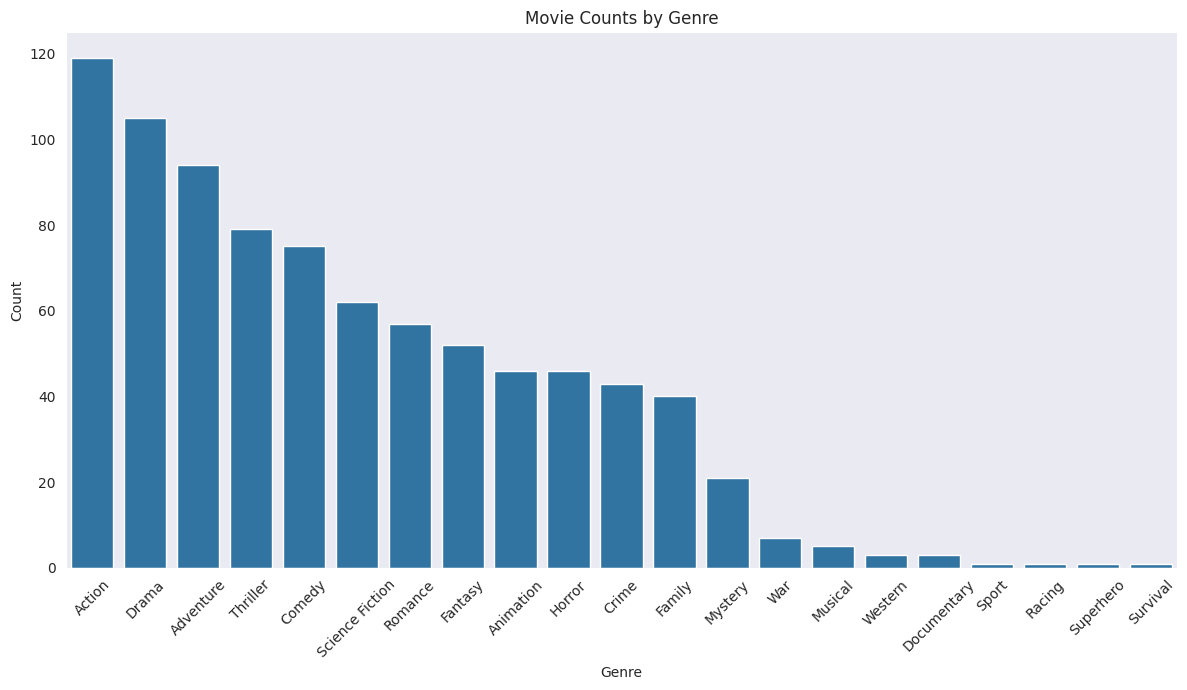

In [291]:
# lets have some bar plot showing count by genre
import matplotlib.pyplot as plt
import seaborn as sns

# Count movies per genre
genre_counts = exploded_genre_rating['genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

plt.figure(figsize=(12, 7))
sns.barplot(x='Genre', y='Count', data=genre_counts)
plt.xticks(rotation=45)
plt.title('Movie Counts by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


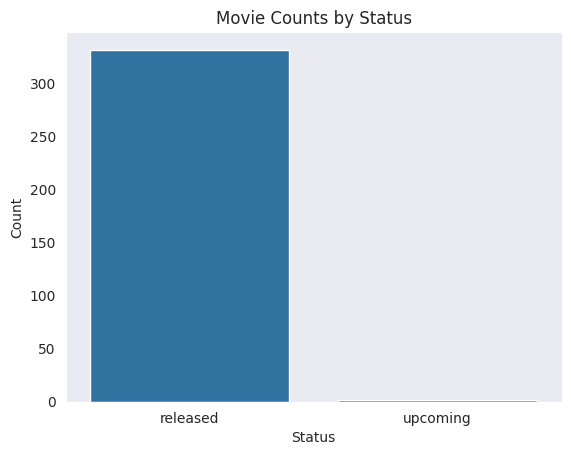

In [292]:

# lest plot count of released and upcomming.
status_counts = movies_df['status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

sns.barplot(x='Status', y='Count', data=status_counts)
plt.title('Movie Counts by Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

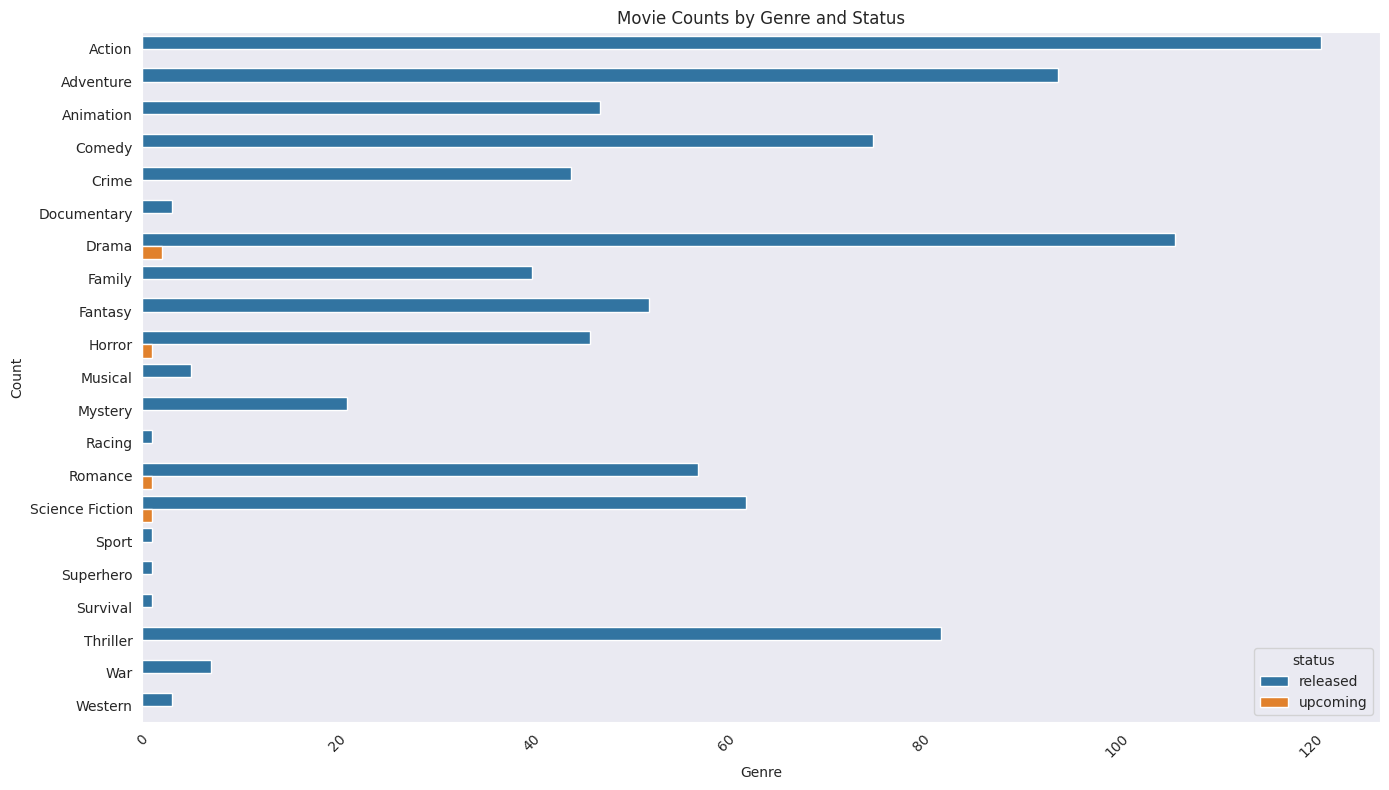

In [293]:
# lets have the count plot with status
movies_exploded = movies_df.explode('genre')

# Now group by genre (as a string) and status
counts_by_genre_status = (
    movies_exploded.groupby(['genre', 'status'])
    .size()
    .reset_index(name='Count')
)

plt.figure(figsize=(14, 8))
sns.barplot(y='genre', x='Count', hue='status', data=counts_by_genre_status)
plt.xticks(rotation=45)
plt.title('Movie Counts by Genre and Status')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### **Relationships & Correlations**

<Axes: title={'center': 'Scatter Plot of Average Rating vs Age Rating'}, xlabel='Age Rating', ylabel='Average Rating'>

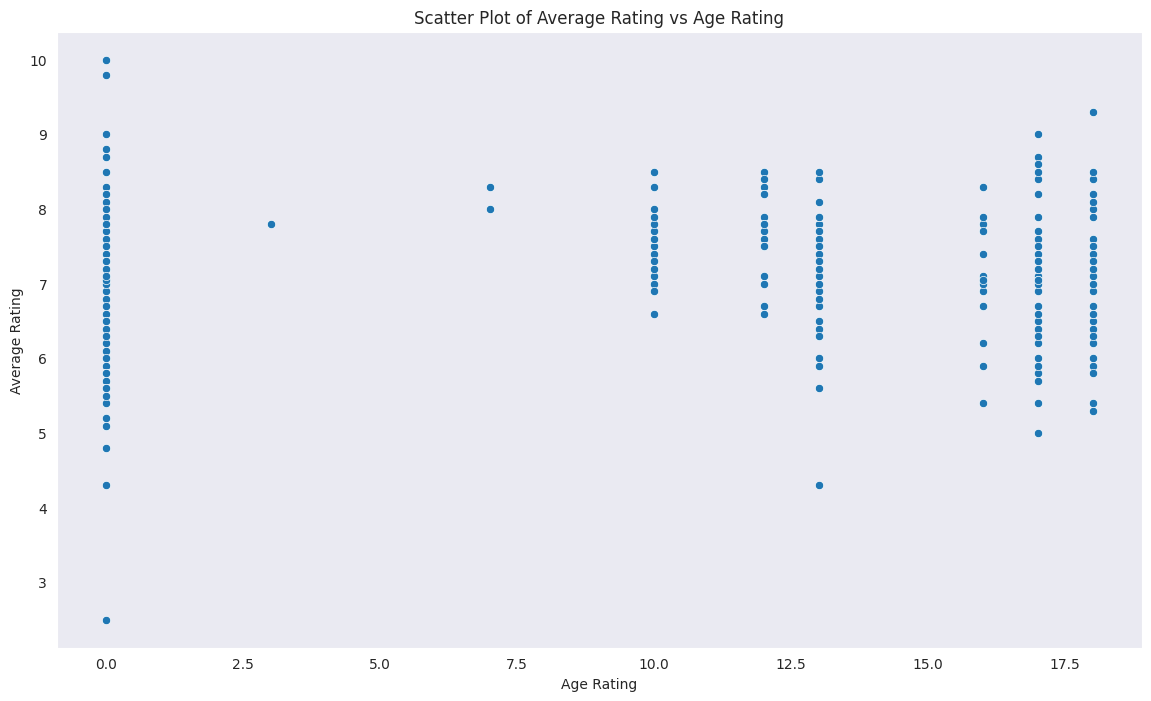

In [294]:
from sklearn.impute import SimpleImputer
# age rating vs average rating
plt.figure(figsize=(14, 8));

# lets create a temp df with filtered values handeling null
df = movies_df.copy()
# df["averageRating"].fillna(df["averageRating"].mean() , inplace = True)
# df["ageRating"].fillna(0 , inplace= True)

imputer_mean = SimpleImputer(strategy="mean")
imputer_zero = SimpleImputer(strategy="constant" , fill_value= 0)
df["averageRating"] = imputer_mean.fit_transform(df[["averageRating"]])
df["ageRating"] = imputer_zero.fit_transform(df[["ageRating"]])


# now lets create the plot
plt.xlabel("Age Rating")
plt.ylabel("Average Rating")
plt.title("Scatter Plot of Average Rating vs Age Rating")
sns.scatterplot(x="ageRating" ,y = "averageRating" , data = df)

ok we cant really understand any relation from this ❗

In [295]:
# lets drop __v since its not really use fill
df.drop(axis = 0 , columns=["__v"] , inplace=True)
# lets find all the numeric columns
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['averageRating', 'runTime', 'ageRating'], dtype='object')

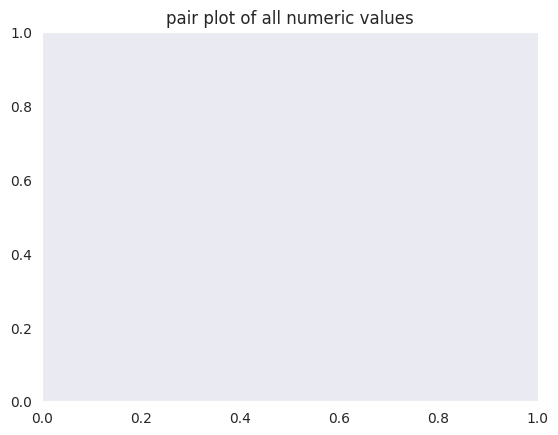

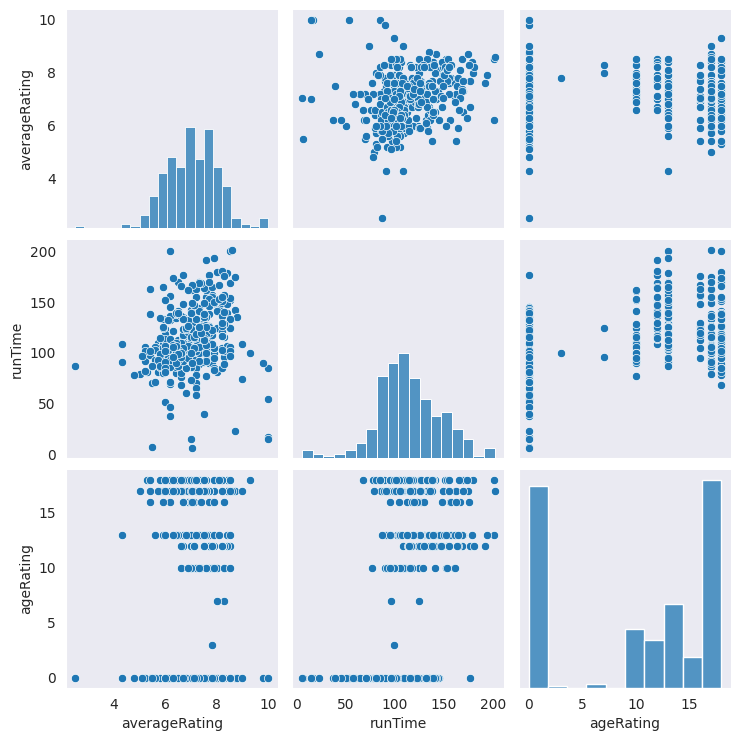

In [296]:
# lets also impute runtime with mean
df["runTime"] = imputer_mean.fit_transform(df[["runTime"]])

# lets now plot the pair plot
plt.title("pair plot of all numeric values")
sns.pairplot( df[num_cols])

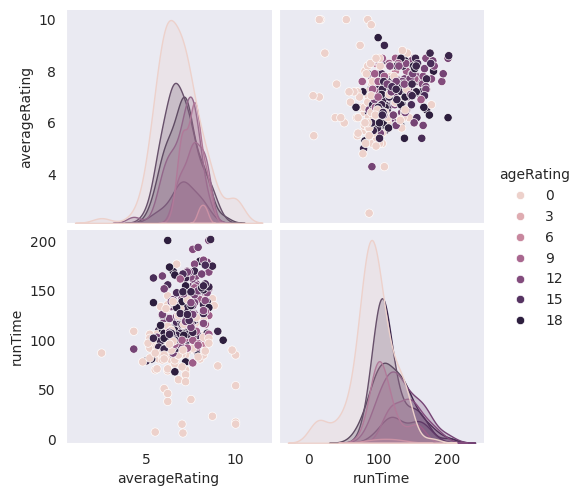

In [297]:
# with age as hue
sns.pairplot( df[num_cols] , hue= "ageRating")

No clear or strong correlation between averageRating/runTime and ageRating is visible.

imputing age with 0 is likely not a good option .


Text(0.5, 1.0, 'Correlation Heatmap numeric data')

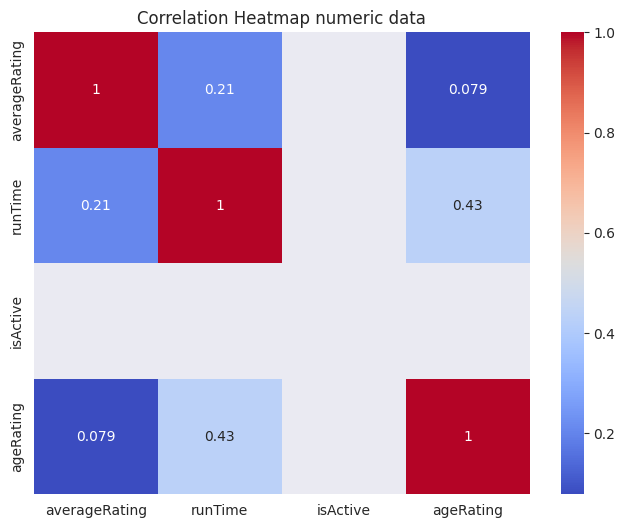

In [298]:
# lets plot a cor realtion heat map

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap numeric data")


No strong correlations .
runTime & ageRating	0.44  has the highest corelation which is not much at all

# **Data cleaning**

now lets clear all the unwanted data from the data frame as per our observation and also impute missing values .

In [388]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             334 non-null    object             
 1   title           334 non-null    object             
 2   description     334 non-null    object             
 3   averageRating   327 non-null    float64            
 4   genre           334 non-null    object             
 5   releaseDate     334 non-null    datetime64[ns, UTC]
 6   cast            334 non-null    object             
 7   directors       334 non-null    object             
 8   runTime         334 non-null    int64              
 9   languages       334 non-null    object             
 10  posterUrl       334 non-null    object             
 11  backdropUrl     334 non-null    object             
 12  isActive        334 non-null    bool               
 13  status          334 non-null    obj

In [389]:
# lets first create a copy of the data
df_clean = movies_df.copy()

df_clean = df_clean.set_index("_id")

# lets remove any inactive movies before droping the column
df_clean = df_clean[df_clean["isActive"] == True]

# lest first define all the columns to drop
columns_to_drop = [
    '__v',           # MongoDB version key mot importent
    'updatedAt',     # Not needed for training
    'backdropUrl',   # URL - not useful for training
    'posterUrl',     # URL - not useful for training
    'isActive',      # We only want active data
    'youtubeVideoId' # Video ID - not useful for training
]

# drop all the columsn
df_clean = df_clean.drop(columns= columns_to_drop)
print(f"Shape before dropping: {df_clean.shape}")
print(f"Shape after dropping: {df_clean.shape}")

df_clean.head()

Shape before dropping: (334, 13)
Shape after dropping: (334, 13)


,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,status,tags,ageRating,createdAt
_id,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100,"[english, hindi]",released,"[Family Friendly, Critically Acclaimed, Charac...",3,2025-09-09 10:16:23.718000+00:00
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155,[japanese],released,"[Family Friendly, Critically Acclaimed, Charac...",13,2025-09-15 16:45:37.477000+00:00
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91,[english],released,"[Attack, Privacy, Surveillance, Cybersecurity]",13,2025-09-15 16:54:08.362000+00:00
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129,"[english, spanish]",released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0,2025-09-16 03:13:21.693000+00:00
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135,[english],released,"[Supernatural, Exorcism, Haunted house, Sequel...",18,2025-09-16 03:17:33.416000+00:00


In [390]:
from sklearn.impute import SimpleImputer

# now lets imput out numeric data with mean
num_cols = df_clean.select_dtypes(include='number').columns

# define imputer
imputer_mean = SimpleImputer(strategy="mean")

df_clean[num_cols] = imputer_mean.fit_transform(df_clean[num_cols])

df_clean.head()


,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,status,tags,ageRating,createdAt
_id,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100.0,"[english, hindi]",released,"[Family Friendly, Critically Acclaimed, Charac...",3.0,2025-09-09 10:16:23.718000+00:00
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155.0,[japanese],released,"[Family Friendly, Critically Acclaimed, Charac...",13.0,2025-09-15 16:45:37.477000+00:00
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91.0,[english],released,"[Attack, Privacy, Surveillance, Cybersecurity]",13.0,2025-09-15 16:54:08.362000+00:00
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129.0,"[english, spanish]",released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0.0,2025-09-16 03:13:21.693000+00:00
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135.0,[english],released,"[Supernatural, Exorcism, Haunted house, Sequel...",18.0,2025-09-16 03:17:33.416000+00:00


In [391]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 68bffe772be9067493eab974 to 69216c9826548e7ab0b684d4
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   title          334 non-null    object             
 1   description    334 non-null    object             
 2   averageRating  334 non-null    float64            
 3   genre          334 non-null    object             
 4   releaseDate    334 non-null    datetime64[ns, UTC]
 5   cast           334 non-null    object             
 6   directors      334 non-null    object             
 7   runTime        334 non-null    float64            
 8   languages      334 non-null    object             
 9   status         334 non-null    object             
 10  tags           334 non-null    object             
 11  ageRating      334 non-null    float64            
 12  createdAt      334 non-null    datetime64[ns, UTC]
dtypes: datetime

In [392]:
# lest check if we have any null
null_counts = df_clean.isnull().sum()
null_counts

,0
title,0
description,0
averageRating,0
genre,0
releaseDate,0
cast,0
directors,0
runTime,0
languages,0
status,0


In [393]:
total_null = df_clean.isnull().sum().sum()
print("total null in data frame" , total_null)

total null in data frame 0


lets only check for numerick values since thats what we really handeled .

In [394]:
null_counts = df_clean[num_cols].isnull().sum()
null_counts

,0
averageRating,0
runTime,0
ageRating,0


no null values great .

In [395]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 68bffe772be9067493eab974 to 69216c9826548e7ab0b684d4
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   title          334 non-null    object             
 1   description    334 non-null    object             
 2   averageRating  334 non-null    float64            
 3   genre          334 non-null    object             
 4   releaseDate    334 non-null    datetime64[ns, UTC]
 5   cast           334 non-null    object             
 6   directors      334 non-null    object             
 7   runTime        334 non-null    float64            
 8   languages      334 non-null    object             
 9   status         334 non-null    object             
 10  tags           334 non-null    object             
 11  ageRating      334 non-null    float64            
 12  createdAt      334 non-null    datetime64[ns, UTC]
dtypes: datetime

In [396]:
# convert to date time
df_clean['releaseDate'] = pd.to_datetime(df_clean['releaseDate'], errors='coerce')
df_clean['createdAt'] = pd.to_datetime(df_clean['createdAt'], errors='coerce')

# lets now handle any missing values in release date
# currently we dont have any missing value but it can be there in future
# lets imput this with median()
median_date = df_clean['releaseDate'].median()
df_clean['releaseDate'] = df_clean['releaseDate'].fillna(median_date)
df_clean.head()

,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,status,tags,ageRating,createdAt
_id,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100.0,"[english, hindi]",released,"[Family Friendly, Critically Acclaimed, Charac...",3.0,2025-09-09 10:16:23.718000+00:00
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155.0,[japanese],released,"[Family Friendly, Critically Acclaimed, Charac...",13.0,2025-09-15 16:45:37.477000+00:00
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91.0,[english],released,"[Attack, Privacy, Surveillance, Cybersecurity]",13.0,2025-09-15 16:54:08.362000+00:00
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129.0,"[english, spanish]",released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0.0,2025-09-16 03:13:21.693000+00:00
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135.0,[english],released,"[Supernatural, Exorcism, Haunted house, Sequel...",18.0,2025-09-16 03:17:33.416000+00:00


In [397]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 68bffe772be9067493eab974 to 69216c9826548e7ab0b684d4
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   title          334 non-null    object             
 1   description    334 non-null    object             
 2   averageRating  334 non-null    float64            
 3   genre          334 non-null    object             
 4   releaseDate    334 non-null    datetime64[ns, UTC]
 5   cast           334 non-null    object             
 6   directors      334 non-null    object             
 7   runTime        334 non-null    float64            
 8   languages      334 non-null    object             
 9   status         334 non-null    object             
 10  tags           334 non-null    object             
 11  ageRating      334 non-null    float64            
 12  createdAt      334 non-null    datetime64[ns, UTC]
dtypes: datetime

Now lets go on and deal with missing values in our array type feilds in case they are toatlly missing or an empty array lest fill them up by unknown . and add a feild with IsMissing and set to true

In [398]:
# for doing this lets create a function since we have a lot of columns
def impute_array_col (df , col_name , fill_value = ["Unknown"]):
  # impute the missing values first
  filled_col = df[col_name].apply(lambda x: x if isinstance(x , list) and len(x) > 0 else fill_value)
  # create a flag column for missing data
  flag_col = df[col_name].apply(lambda x : not isinstance(x , list) or len(x) == 0)
  # assign it back to the main dataframe
  df[col_name] = filled_col
  df[col_name + "IsMissing"] = flag_col
  return df


In [399]:
# now lets use out util on the array columns
impute_array_col(df = df_clean , col_name = "genre");
impute_array_col(df = df_clean , col_name = "cast");
impute_array_col(df = df_clean , col_name = "directors");
impute_array_col(df = df_clean , col_name = "languages");
impute_array_col(df = df_clean , col_name = "tags");

df_clean.head()

,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,status,tags,ageRating,createdAt,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing
_id,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100.0,"[english, hindi]",released,"[Family Friendly, Critically Acclaimed, Charac...",3.0,2025-09-09 10:16:23.718000+00:00,False,False,False,False,False
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155.0,[japanese],released,"[Family Friendly, Critically Acclaimed, Charac...",13.0,2025-09-15 16:45:37.477000+00:00,False,False,False,False,False
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91.0,[english],released,"[Attack, Privacy, Surveillance, Cybersecurity]",13.0,2025-09-15 16:54:08.362000+00:00,False,False,False,False,False
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129.0,"[english, spanish]",released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0.0,2025-09-16 03:13:21.693000+00:00,False,False,False,False,False
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135.0,[english],released,"[Supernatural, Exorcism, Haunted house, Sequel...",18.0,2025-09-16 03:17:33.416000+00:00,False,False,False,False,False


In [400]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 68bffe772be9067493eab974 to 69216c9826548e7ab0b684d4
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               334 non-null    object             
 1   description         334 non-null    object             
 2   averageRating       334 non-null    float64            
 3   genre               334 non-null    object             
 4   releaseDate         334 non-null    datetime64[ns, UTC]
 5   cast                334 non-null    object             
 6   directors           334 non-null    object             
 7   runTime             334 non-null    float64            
 8   languages           334 non-null    object             
 9   status              334 non-null    object             
 10  tags                334 non-null    object             
 11  ageRating           334 non-null    float64            
 1

In [401]:
# lets handle string values now and  we only have description that can be missing .
df_clean["description"] = df_clean["description"].apply(lambda x : x if x.strip() else "No description available")

# we will hold off on adding anothor filed stating isMissing since description missing is very rare
df_clean

,title,description,averageRating,genre,releaseDate,cast,directors,runTime,languages,status,tags,ageRating,createdAt,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing
_id,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,"[Animation, Family]",2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100.0,"[english, hindi]",released,"[Family Friendly, Critically Acclaimed, Charac...",3.0,2025-09-09 10:16:23.718000+00:00,False,False,False,False,False
68c842b124e7e5c3d5ea6401,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,"[Animation, Action, Fantasy, Thriller]",2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155.0,[japanese],released,"[Family Friendly, Critically Acclaimed, Charac...",13.0,2025-09-15 16:45:37.477000+00:00,False,False,False,False,False
68c844b0914f46567ea6a865,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,"[Science Fiction, Thriller, War]",2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91.0,[english],released,"[Attack, Privacy, Surveillance, Cybersecurity]",13.0,2025-09-15 16:54:08.362000+00:00,False,False,False,False,False
68c8d5d1bffe0597fd205e35,Weapons,When all but one child from the same class mys...,7.4,"[Horror, Mystery]",2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129.0,"[english, spanish]",released,"[Cop, Teacher, Trance, Witchcraft, Multiple st...",0.0,2025-09-16 03:13:21.693000+00:00,False,False,False,False,False
68c8d6cd45b97c9ac2d3c264,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,[Horror],2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135.0,[english],released,"[Supernatural, Exorcism, Haunted house, Sequel...",18.0,2025-09-16 03:17:33.416000+00:00,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690a1990d310dbfaf41b46c5,M3GAN 2.0,After the underlying tech for M3GAN is stolen ...,7.4,"[Action, Science Fiction, Thriller]",2025-06-25 00:00:00+00:00,"[Allison Williams, Violet McGraw, Amie Donald,...",[Gerard Johnstone],120.0,"[dutch, english]",released,"[Artificial intelligence, Sequel, Satirical]",16.0,2025-11-04 15:19:44.707000+00:00,False,False,False,False,False
6914083de2bc639771474876,Roofman,A former Army Ranger and struggling father tur...,7.3,"[Comedy, Drama, Crime]",2025-10-08 00:00:00+00:00,"[Channing Tatum, Kirsten Dunst, Ben Mendelsohn...",[Derek Cianfrance],126.0,[english],released,"[Dark comedy, Based on true Story]",17.0,2025-11-12 04:08:29.392000+00:00,False,False,False,False,False
69140a28e2bc6397714748d1,Death of a Unicorn,A father and daughter accidentally hit and kil...,6.4,"[Horror, Fantasy, Comedy]",2025-03-27 00:00:00+00:00,"[Paul Rudd, Jenna Ortega, Will Poulter, Richar...",[Alex Scharfman],107.0,[english],released,"[Fantasy World, Dark comedy, Dark, Critically ...",17.0,2025-11-12 04:16:40.224000+00:00,False,False,False,False,False


In [402]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 68bffe772be9067493eab974 to 69216c9826548e7ab0b684d4
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               334 non-null    object             
 1   description         334 non-null    object             
 2   averageRating       334 non-null    float64            
 3   genre               334 non-null    object             
 4   releaseDate         334 non-null    datetime64[ns, UTC]
 5   cast                334 non-null    object             
 6   directors           334 non-null    object             
 7   runTime             334 non-null    float64            
 8   languages           334 non-null    object             
 9   status              334 non-null    object             
 10  tags                334 non-null    object             
 11  ageRating           334 non-null    float64            
 1

In [403]:
# now lets handle outliers .
# we will need to handle it for runTime and releaseDate

#lest use IQR to handle runtime  (The Interquartile Rang)

Q1 = df_clean["runTime"].quantile(0.10)#first quartile)
Q3 = df_clean["runTime"].quantile(0.85)#third quartile

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean["runTime"] = df_clean["runTime"].clip(lower= lower_bound , upper=upper_bound)

df_clean["runTime"].head()

,runTime
_id,
68bffe772be9067493eab974,100.0
68c842b124e7e5c3d5ea6401,155.0
68c844b0914f46567ea6a865,91.0
68c8d5d1bffe0597fd205e35,129.0
68c8d6cd45b97c9ac2d3c264,135.0


In [404]:
# now lets handle release year .
# lets manually define this bounds
lower_bound = pd.Timestamp(year=1900, month=1, day=1 , tz='UTC')
upper_bound = pd.Timestamp.now( tz='UTC').normalize()

df_clean['releaseDate'] = df_clean['releaseDate'].clip(lower=lower_bound, upper=upper_bound)

df_clean["releaseDate"]

,releaseDate
_id,
68bffe772be9067493eab974,2003-05-30 00:00:00+00:00
68c842b124e7e5c3d5ea6401,2025-07-18 00:00:00+00:00
68c844b0914f46567ea6a865,2025-07-29 00:00:00+00:00
68c8d5d1bffe0597fd205e35,2025-08-04 00:00:00+00:00
68c8d6cd45b97c9ac2d3c264,2025-09-03 00:00:00+00:00
...,...
690a1990d310dbfaf41b46c5,2025-06-25 00:00:00+00:00
6914083de2bc639771474876,2025-10-08 00:00:00+00:00
69140a28e2bc6397714748d1,2025-03-27 00:00:00+00:00


# Feature engineering

In [405]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 334 entries, 68bffe772be9067493eab974 to 69216c9826548e7ab0b684d4
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   title               334 non-null    object             
 1   description         334 non-null    object             
 2   averageRating       334 non-null    float64            
 3   genre               334 non-null    object             
 4   releaseDate         334 non-null    datetime64[ns, UTC]
 5   cast                334 non-null    object             
 6   directors           334 non-null    object             
 7   runTime             334 non-null    float64            
 8   languages           334 non-null    object             
 9   status              334 non-null    object             
 10  tags                334 non-null    object             
 11  ageRating           334 non-null    float64            
 1

Here we will focus of extracting information from our columns into some thing that is more use full to our model we , first focus on our array feilds .

In [406]:
# first lets encode status with binary for movies we see that itonly has 2 status
df_clean["status"].unique()

array(['released', 'upcoming'], dtype=object)

In [407]:
# we will be encoding released = 1 , upcoming = 0 ()
# binary encoding

df_clean["status"]  = (df_clean["status"] == "released").astype(int)

df_clean["status"]

,status
_id,
68bffe772be9067493eab974,1
68c842b124e7e5c3d5ea6401,1
68c844b0914f46567ea6a865,1
68c8d5d1bffe0597fd205e35,1
68c8d6cd45b97c9ac2d3c264,1
...,...
690a1990d310dbfaf41b46c5,1
6914083de2bc639771474876,1
69140a28e2bc6397714748d1,1


In [408]:
# now lets handle columns like language , genre , tags
# we will be multi hot encoding them .

# lets first handle the geners
mlb_genre = MultiLabelBinarizer()
geners_encoded = mlb_genre.fit_transform(df_clean["genre"]);
genres_df = pd.DataFrame(geners_encoded, columns=mlb_genre.classes_)

# we drop unknown since its not required
genres_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

genres_df


,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Horror,...,Mystery,Racing,Romance,Science Fiction,Sport,Superhero,Survival,Thriller,War,Western
0,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,0
3,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
330,0,0,0,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
331,0,0,0,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
332,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [409]:
# lets handle the languages
mlb_languages =  MultiLabelBinarizer()
language_encoded = mlb_languages.fit_transform(df_clean["languages"]);
languages_df = pd.DataFrame(language_encoded , columns= mlb_languages.classes_)

# we drop unknown since its not required
languages_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

languages_df.head(10)

,abkhazian,arabic,armenian,belarusian,cantonese,czech,danish,dutch,dzongkha,english,...,tamil,telugu,thai,turkish,ukrainian,urdu,venda,vietnamese,xhosa,yiddish
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [410]:
# now for tags we will first fint the top 30 tags and categorize any other under others .

# lets get all flags
all_tags = [tag for tags in df_clean["tags"] for tag in tags]

unique_tags = set(all_tags)  # Set contains only unique tag names

print(f"Total unique tags: {len(unique_tags)}")
print(f"Unique tags: {unique_tags}")

Total unique tags: 80
Unique tags: {'Friendship', 'Surveillance', 'Satirical', 'Terrorist plot', 'Supervillain', 'Dystopian', 'Antagonistic', 'Wedding', 'Suspense', 'Exorcism', 'Political', 'Dark', 'Battle', 'Privacy', 'Trance', 'Kidnapping', 'Ghost', 'Reboot', 'Thief', 'Remake', 'Gloomy', 'Religion', 'Demon', 'Martial arts', 'Spy', 'Adult', 'Spell', 'Coming of Age', 'Aggressive', 'Award-winning', 'Sequel', 'Exhilarated', 'Motorsport', 'Orphan', 'Post-Apocalyptic', 'Haunted house', 'Based on true Story', 'Character-Driven', 'Family Friendly', 'Government', 'Super power', 'Cybersecurity', 'Save the world', 'Historical Fiction', 'K-pop', 'Attack', 'Shounen', 'Romantic', 'Character-driven', 'Politics', 'Multiple storylines', 'Assassin', 'Fantasy World', 'Cop', '3d animation', 'Female protagonist', 'Time Travel', 'Heist', 'Unknown', 'Infiltration', 'Cult', 'Teacher', 'Detective', 'Warrior', 'History', 'Witchcraft', 'Violent', 'Revenge', 'Kung fu', 'Critically Acclaimed', 'Dark comedy', 'Sl

In [411]:
# ok now lets find  the top 30 tags

tag_counts = Counter(all_tags);

top_tags = [tag for tag , count in tag_counts.most_common(30) ]

top_tags


['Character-Driven',
 'Critically Acclaimed',
 'Dark comedy',
 'Unknown',
 'Family Friendly',
 'Sequel',
 'Fantasy World',
 '3d animation',
 'Supervillain',
 'Friendship',
 'Supernatural',
 'Adult',
 'Revenge',
 'Demon',
 'Dystopian',
 'Witchcraft',
 'Ghost',
 'Remake',
 'Battle',
 'Aggressive',
 'Super power',
 'Artificial intelligence',
 'Female protagonist',
 'Cop',
 'Spirit',
 'Based on true Story',
 'Suspense',
 'Award-winning',
 'Psychological',
 'Romantic']

In [412]:
# now let's do the multi encoding for tags
mlb_tags =  MultiLabelBinarizer()
tags_encoder = mlb_tags.fit_transform(df_clean["tags"])
tags_df = pd.DataFrame(tags_encoder , columns =mlb_tags.classes_ )

# now lets only store top 30 columns
tags_df = tags_df[top_tags]

# we drop unknown since its not required
tags_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

tags_df.head(10)


,Character-Driven,Critically Acclaimed,Dark comedy,Family Friendly,Sequel,Fantasy World,3d animation,Supervillain,Friendship,Supernatural,...,Super power,Artificial intelligence,Female protagonist,Cop,Spirit,Based on true Story,Suspense,Award-winning,Psychological,Romantic
0,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
5,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,1,0,0,0


In [413]:
tags_df.shape

(334, 29)

In [414]:
languages_df.shape

(334, 50)

In [415]:
genres_df.shape

(334, 21)

In [416]:
df_clean.shape

(334, 18)

In [417]:
# now lets add all the data to df_clean
df_clean = df_clean.reset_index(drop=True) # we need to do this for proper join
df_clean_combined = df_clean.join([tags_df, languages_df, genres_df])

# lest drop the columns we dont require like tags , languages and genere
df_clean_combined.drop(columns= ["tags" , "genre" , "languages"] , inplace=True)

df_clean_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Columns: 115 entries, title to Western
dtypes: bool(5), datetime64[ns, UTC](2), float64(3), int64(101), object(4)
memory usage: 288.8+ KB


In [418]:
df_clean_combined.head()

,title,description,averageRating,releaseDate,cast,directors,runTime,status,ageRating,createdAt,...,Mystery,Racing,Romance,Science Fiction,Sport,Superhero,Survival,Thriller,War,Western
0,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,2003-05-30 00:00:00+00:00,"[Albert Brooks, Ellen DeGeneres, Alexander Gou...",[Andrew Stanton],100.0,1,3.0,2025-09-09 10:16:23.718000+00:00,...,0,0,0,0,0,0,0,0,0,0
1,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,2025-07-18 00:00:00+00:00,"[Natsuki Hanae, Hiro Shimono, Takahiro Sakurai...",[Haruo Sotozaki],155.0,1,13.0,2025-09-15 16:45:37.477000+00:00,...,0,0,0,0,0,0,0,1,0,0
2,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,2025-07-29 00:00:00+00:00,"[Ice Cube, Eva Longoria, Clark Gregg, Iman Ben...",[Rich Lee],91.0,1,13.0,2025-09-15 16:54:08.362000+00:00,...,0,0,0,1,0,0,0,1,1,0
3,Weapons,When all but one child from the same class mys...,7.4,2025-08-04 00:00:00+00:00,"[Julia Garner, Josh Brolin, Alden Ehrenreich, ...",[Zach Cregger],129.0,1,0.0,2025-09-16 03:13:21.693000+00:00,...,1,0,0,0,0,0,0,0,0,0
4,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,2025-09-03 00:00:00+00:00,"[Vera Farmiga, Patrick Wilson, Mia Tomlinson, ...",[Michael Chaves],135.0,1,18.0,2025-09-16 03:17:33.416000+00:00,...,0,0,0,0,0,0,0,0,0,0


In [419]:
df_clean_combined.columns

Index(['title', 'description', 'averageRating', 'releaseDate', 'cast',
       'directors', 'runTime', 'status', 'ageRating', 'createdAt',
       ...
       'Mystery', 'Racing', 'Romance', 'Science Fiction', 'Sport', 'Superhero',
       'Survival', 'Thriller', 'War', 'Western'],
      dtype='object', length=115)

In [420]:
df_clean_combined.shape

(334, 115)

In [421]:
# now for columns like cast , directors we will be hasing them :) they are highly cardinal no way to multi encode them

# first lets handler cast
# lest convert list to a string

df_clean["cast_str"] = df_clean["cast"].apply(lambda x : ' '.join(x) if isinstance(x, list) else str(x))

df_clean["cast_str"].head()


,cast_str
0,Albert Brooks Ellen DeGeneres Alexander Gould ...
1,Natsuki Hanae Hiro Shimono Takahiro Sakurai Ak...
2,Ice Cube Eva Longoria Clark Gregg Iman Benson ...
3,Julia Garner Josh Brolin Alden Ehrenreich Aust...
4,Vera Farmiga Patrick Wilson Mia Tomlinson Ben ...


In [422]:
cast_hasher = HashingVectorizer(n_features=120 , alternate_sign=False , norm=None)
cast_features = cast_hasher.fit_transform(df_clean["cast_str"])
cast_df = pd.DataFrame(cast_features.toarray() , columns=[f'cast_hash_{i}' for i in range(120)] )

cast_df.head(10)

,cast_hash_0,cast_hash_1,cast_hash_2,cast_hash_3,cast_hash_4,cast_hash_5,cast_hash_6,cast_hash_7,cast_hash_8,cast_hash_9,...,cast_hash_110,cast_hash_111,cast_hash_112,cast_hash_113,cast_hash_114,cast_hash_115,cast_hash_116,cast_hash_117,cast_hash_118,cast_hash_119
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [423]:
# now lets do the same for directors.

# conver array to string
df_clean["director_str"] = df_clean["directors"].apply(lambda x : ' '.join(x) if isinstance(x, list) else str(x))

# hash and fit
director_hasher = HashingVectorizer(n_features=60 , alternate_sign=False , norm=None)
director_features = director_hasher.fit_transform(df_clean["director_str"])
director_df = pd.DataFrame(director_features.toarray() , columns=[f'director_hash_{i}' for i in range(60)] )
director_df.head(10)

,director_hash_0,director_hash_1,director_hash_2,director_hash_3,director_hash_4,director_hash_5,director_hash_6,director_hash_7,director_hash_8,director_hash_9,...,director_hash_50,director_hash_51,director_hash_52,director_hash_53,director_hash_54,director_hash_55,director_hash_56,director_hash_57,director_hash_58,director_hash_59
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [424]:
# now lets combine the data set
df_clean_combined = df_clean_combined.join([director_df, cast_df])

# lest drop the original director and cast
df_clean_combined.drop(columns=["directors" , "cast"] , inplace = True)


df_clean_combined.head(10)

,title,description,averageRating,releaseDate,runTime,status,ageRating,createdAt,genreIsMissing,castIsMissing,...,cast_hash_110,cast_hash_111,cast_hash_112,cast_hash_113,cast_hash_114,cast_hash_115,cast_hash_116,cast_hash_117,cast_hash_118,cast_hash_119
0,Finding Nemo. K,"Nemo, an adventurous young clownfish, is unexp...",7.8,2003-05-30 00:00:00+00:00,100.0,1,3.0,2025-09-09 10:16:23.718000+00:00,False,False,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Demon Slayer: Kimetsu no Yaiba Infinity Castle,The Demon Slayer Corps are drawn into the Infi...,7.6,2025-07-18 00:00:00+00:00,155.0,1,13.0,2025-09-15 16:45:37.477000+00:00,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,War of the Worlds,Will Radford is a top analyst for Homeland Sec...,4.3,2025-07-29 00:00:00+00:00,91.0,1,13.0,2025-09-15 16:54:08.362000+00:00,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Weapons,When all but one child from the same class mys...,7.4,2025-08-04 00:00:00+00:00,129.0,1,0.0,2025-09-16 03:13:21.693000+00:00,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,The Conjuring: Last Rites,Paranormal investigators Ed and Lorraine Warre...,6.7,2025-09-03 00:00:00+00:00,135.0,1,18.0,2025-09-16 03:17:33.416000+00:00,False,False,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Detective Dee: The Four Heavenly Kings,"Dee, the detective serving Chinese empress Wu ...",6.2,2018-07-27 00:00:00+00:00,132.0,1,0.0,2025-09-16 03:35:42.260000+00:00,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Get Fast,When The Thief’s partner is kidnapped after st...,5.8,2024-12-12 00:00:00+00:00,88.0,1,17.0,2025-09-16 03:39:55.754000+00:00,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7,Nobody 2,Former assassin Hutch Mansell takes his family...,7.3,2025-08-13 00:00:00+00:00,89.0,1,18.0,2025-09-16 03:46:05.421000+00:00,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,The Naked Gun,Only one man has the particular set of skills....,6.7,2025-07-30 00:00:00+00:00,85.0,1,18.0,2025-09-16 03:48:26.431000+00:00,False,False,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
9,Stockholm Bloodbath,"In 1520, the notorious and power-hungry Danish...",6.2,2024-01-19 00:00:00+00:00,145.0,1,0.0,2025-09-16 04:05:07.134000+00:00,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [425]:
# now lets deal with description column
# we will vectorize this

tfidf = TfidfVectorizer(max_features= 100)
description_features = tfidf.fit_transform(df_clean["description"])

description_df = pd.DataFrame(description_features.toarray() , columns = [f"desc_tfidf_{i}" for i in range(description_features.shape[1])])

description_df.head(10)


,desc_tfidf_0,desc_tfidf_1,desc_tfidf_2,desc_tfidf_3,desc_tfidf_4,desc_tfidf_5,desc_tfidf_6,desc_tfidf_7,desc_tfidf_8,desc_tfidf_9,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,0.0,0.000000,0.000000,0.000000,0.163914,0.199499,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.244132
1,0.0,0.000000,0.346465,0.000000,0.000000,0.130230,0.288770,0.225957,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
2,0.0,0.000000,0.000000,0.000000,0.310342,0.094429,0.000000,0.000000,0.000000,0.000000,...,0.0,0.172819,0.0,0.239364,0.000000,0.0,0.210843,0.0,0.0,0.000000
3,0.0,0.000000,0.000000,0.302989,0.000000,0.000000,0.000000,0.000000,0.263833,0.000000,...,0.0,0.220741,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
4,0.0,0.000000,0.000000,0.000000,0.000000,0.167030,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
5,0.0,0.000000,0.000000,0.000000,0.000000,0.159262,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
6,0.0,0.162982,0.000000,0.000000,0.133560,0.081277,0.000000,0.000000,0.000000,0.000000,...,0.0,0.148749,0.0,0.412054,0.239874,0.0,0.000000,0.0,0.0,0.000000
7,0.0,0.000000,0.000000,0.000000,0.000000,0.130380,0.000000,0.000000,0.000000,0.366459,...,0.0,0.000000,0.0,0.000000,0.192395,0.0,0.000000,0.0,0.0,0.000000
8,0.0,0.000000,0.000000,0.000000,0.000000,0.166126,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.370928,0.0,0.0,0.000000
9,0.0,0.000000,0.000000,0.000000,0.000000,0.227624,0.168243,0.131647,0.000000,0.000000,...,0.0,0.138862,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000


In [426]:
# Sentence Embedding/Transforme try  this out in cace it has better results
# from sentence_transformers import SentenceTransformer

In [427]:
# lets combien the data set
df_clean_combined = df_clean_combined.join([description_df])

# lest now drop title and description , since titile is unique we dont need it for tarining .
df_clean_combined.drop(columns=["description" , "title"] , inplace=True)
df_clean_combined.head(10)

,averageRating,releaseDate,runTime,status,ageRating,createdAt,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,7.8,2003-05-30 00:00:00+00:00,100.0,1,3.0,2025-09-09 10:16:23.718000+00:00,False,False,False,False,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.244132
1,7.6,2025-07-18 00:00:00+00:00,155.0,1,13.0,2025-09-15 16:45:37.477000+00:00,False,False,False,False,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
2,4.3,2025-07-29 00:00:00+00:00,91.0,1,13.0,2025-09-15 16:54:08.362000+00:00,False,False,False,False,...,0.0,0.172819,0.0,0.239364,0.000000,0.0,0.210843,0.0,0.0,0.000000
3,7.4,2025-08-04 00:00:00+00:00,129.0,1,0.0,2025-09-16 03:13:21.693000+00:00,False,False,False,False,...,0.0,0.220741,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
4,6.7,2025-09-03 00:00:00+00:00,135.0,1,18.0,2025-09-16 03:17:33.416000+00:00,False,False,False,False,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
5,6.2,2018-07-27 00:00:00+00:00,132.0,1,0.0,2025-09-16 03:35:42.260000+00:00,False,False,False,False,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
6,5.8,2024-12-12 00:00:00+00:00,88.0,1,17.0,2025-09-16 03:39:55.754000+00:00,False,False,False,False,...,0.0,0.148749,0.0,0.412054,0.239874,0.0,0.000000,0.0,0.0,0.000000
7,7.3,2025-08-13 00:00:00+00:00,89.0,1,18.0,2025-09-16 03:46:05.421000+00:00,False,False,False,False,...,0.0,0.000000,0.0,0.000000,0.192395,0.0,0.000000,0.0,0.0,0.000000
8,6.7,2025-07-30 00:00:00+00:00,85.0,1,18.0,2025-09-16 03:48:26.431000+00:00,False,False,False,False,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.370928,0.0,0.0,0.000000
9,6.2,2024-01-19 00:00:00+00:00,145.0,1,0.0,2025-09-16 04:05:07.134000+00:00,False,False,False,False,...,0.0,0.138862,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000


# Normalization

In [428]:
# Convert all boolean columns to 1/0
for col in df_clean_combined.columns:
    if df_clean_combined[col].dtype == 'bool':
        df_clean_combined[col] = df_clean_combined[col].astype(int)

In [429]:
df_clean_combined.head(10)

,averageRating,releaseDate,runTime,status,ageRating,createdAt,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,7.8,2003-05-30 00:00:00+00:00,100.0,1,3.0,2025-09-09 10:16:23.718000+00:00,0,0,0,0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.244132
1,7.6,2025-07-18 00:00:00+00:00,155.0,1,13.0,2025-09-15 16:45:37.477000+00:00,0,0,0,0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
2,4.3,2025-07-29 00:00:00+00:00,91.0,1,13.0,2025-09-15 16:54:08.362000+00:00,0,0,0,0,...,0.0,0.172819,0.0,0.239364,0.000000,0.0,0.210843,0.0,0.0,0.000000
3,7.4,2025-08-04 00:00:00+00:00,129.0,1,0.0,2025-09-16 03:13:21.693000+00:00,0,0,0,0,...,0.0,0.220741,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
4,6.7,2025-09-03 00:00:00+00:00,135.0,1,18.0,2025-09-16 03:17:33.416000+00:00,0,0,0,0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
5,6.2,2018-07-27 00:00:00+00:00,132.0,1,0.0,2025-09-16 03:35:42.260000+00:00,0,0,0,0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
6,5.8,2024-12-12 00:00:00+00:00,88.0,1,17.0,2025-09-16 03:39:55.754000+00:00,0,0,0,0,...,0.0,0.148749,0.0,0.412054,0.239874,0.0,0.000000,0.0,0.0,0.000000
7,7.3,2025-08-13 00:00:00+00:00,89.0,1,18.0,2025-09-16 03:46:05.421000+00:00,0,0,0,0,...,0.0,0.000000,0.0,0.000000,0.192395,0.0,0.000000,0.0,0.0,0.000000
8,6.7,2025-07-30 00:00:00+00:00,85.0,1,18.0,2025-09-16 03:48:26.431000+00:00,0,0,0,0,...,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.370928,0.0,0.0,0.000000
9,6.2,2024-01-19 00:00:00+00:00,145.0,1,0.0,2025-09-16 04:05:07.134000+00:00,0,0,0,0,...,0.0,0.138862,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000


In [430]:
df_clean_combined.iloc[:, :30].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   averageRating         334 non-null    float64            
 1   releaseDate           334 non-null    datetime64[ns, UTC]
 2   runTime               334 non-null    float64            
 3   status                334 non-null    int64              
 4   ageRating             334 non-null    float64            
 5   createdAt             334 non-null    datetime64[ns, UTC]
 6   genreIsMissing        334 non-null    int64              
 7   castIsMissing         334 non-null    int64              
 8   directorsIsMissing    334 non-null    int64              
 9   languagesIsMissing    334 non-null    int64              
 10  tagsIsMissing         334 non-null    int64              
 11  Character-Driven      334 non-null    int64              
 12  Critical

In [431]:
# lets convert out date time  columns to split and use date , year , day
training_data = df_clean_combined.copy()

training_data['releaseDate'] = pd.to_datetime(training_data['releaseDate'], utc=True)

training_data["releaseYear"] = training_data['releaseDate'].dt.year.astype(int)
training_data["releaseMonth"] = training_data['releaseDate'].dt.month.astype(int)
training_data["releaseDay"] = training_data['releaseDate'].dt.day.astype(int)


training_data[['releaseYear' , "releaseMonth" ,  'releaseDay']].head()


,releaseYear,releaseMonth,releaseDay
0,2003,5,30
1,2025,7,18
2,2025,7,29
3,2025,8,4
4,2025,9,3


In [432]:
# lest just do the same fo created at we will just choose to use the year and month
training_data['createdAt'] = pd.to_datetime(training_data['createdAt'], utc=True)

training_data["createdAtMonth"] = training_data['createdAt'].dt.year.astype(int)
training_data["createdAtMonth"] = training_data['createdAt'].dt.month.astype(int)

training_data[['createdAtMonth' , "createdAtMonth"]].head()


,createdAtMonth,createdAtMonth
0,9,9
1,9,9
2,9,9
3,9,9
4,9,9


In [433]:

# lets drop original createdAt , releaseDate
training_data.drop(columns=["createdAt" , "releaseDate"] , inplace=True)

training_data.iloc[:, :30].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   averageRating            334 non-null    float64
 1   runTime                  334 non-null    float64
 2   status                   334 non-null    int64  
 3   ageRating                334 non-null    float64
 4   genreIsMissing           334 non-null    int64  
 5   castIsMissing            334 non-null    int64  
 6   directorsIsMissing       334 non-null    int64  
 7   languagesIsMissing       334 non-null    int64  
 8   tagsIsMissing            334 non-null    int64  
 9   Character-Driven         334 non-null    int64  
 10  Critically Acclaimed     334 non-null    int64  
 11  Dark comedy              334 non-null    int64  
 12  Family Friendly          334 non-null    int64  
 13  Sequel                   334 non-null    int64  
 14  Fantasy World            3

In [434]:
#training_data lets check if all data are in numbers
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Columns: 393 entries, averageRating to createdAtMonth
dtypes: float64(283), int64(110)
memory usage: 1.0 MB


In [435]:
# lets min max normalize runtime all others should be fine by default
min_rt = training_data["runTime"].min()
max_rt = training_data["runTime"].max()

# Normalize runTime to 1-10 range
training_data["runTime"] = 1 + (training_data["runTime"] - min_rt) * (9) / (max_rt - min_rt)  # 9 becaue max = 10 , min = 1  (10 -1 = 9)

training_data["runTime"].head(10)

,runTime
0,5.316327
1,7.841837
2,4.903061
3,6.647959
4,6.923469
5,6.785714
6,4.765306
7,4.811224
8,4.627551
9,7.382653


In [436]:
training_data.head(10)

,averageRating,runTime,status,ageRating,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing,Character-Driven,...,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay,createdAtMonth
0,7.8,5.316327,1,3.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.244132,2003,5,30,9
1,7.6,7.841837,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,7,18,9
2,4.3,4.903061,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.210843,0.0,0.0,0.000000,2025,7,29,9
3,7.4,6.647959,1,0.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,8,4,9
4,6.7,6.923469,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,9,3,9
5,6.2,6.785714,1,0.0,0,0,0,0,0,1,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2018,7,27,9
6,5.8,4.765306,1,17.0,0,0,0,0,0,0,...,0.239874,0.0,0.000000,0.0,0.0,0.000000,2024,12,12,9
7,7.3,4.811224,1,18.0,0,0,0,0,0,0,...,0.192395,0.0,0.000000,0.0,0.0,0.000000,2025,8,13,9
8,6.7,4.627551,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.370928,0.0,0.0,0.000000,2025,7,30,9
9,6.2,7.382653,1,0.0,0,0,0,0,0,1,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2024,1,19,9


Great data is all set for taining

# Training

here we will use 2 models to train out model
1. Cosine Similarity
2. Autoencoder Embedding
3. Jaccard Similarity

we will use what ever we think is better fit

## **Cosine Similarity**

In [ ]:
# lets set the index as _id
training_data["_id"] = movies_df["_id"]
training_data = training_data.set_index("_id")
training_data.head(10)

,averageRating,runTime,status,ageRating,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing,Character-Driven,...,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay,createdAtMonth
_id,,,,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,7.8,5.316327,1,3.0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.2431,2003,5,30,9
68c842b124e7e5c3d5ea6401,7.6,7.841837,1,13.0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0000,2025,7,18,9
68c844b0914f46567ea6a865,4.3,4.903061,1,13.0,0,0,0,0,0,0,...,0.238715,0.000000,0.210167,0.0,0.0,0.0000,2025,7,29,9
68c8d5d1bffe0597fd205e35,7.4,6.647959,1,0.0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0000,2025,8,4,9
68c8d6cd45b97c9ac2d3c264,6.7,6.923469,1,18.0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0000,2025,9,3,9
68c8db0e32672195d9c55006,6.2,6.785714,1,0.0,0,0,0,0,0,1,...,0.000000,0.000000,0.000000,0.0,0.0,0.0000,2018,7,27,9
68c8dc0b403f49b7e9aabf7f,5.8,4.765306,1,17.0,0,0,0,0,0,0,...,0.411023,0.240548,0.000000,0.0,0.0,0.0000,2024,12,12,9
68c8dd7d704c0b56eda4ccaa,7.3,4.811224,1,18.0,0,0,0,0,0,0,...,0.000000,0.193081,0.000000,0.0,0.0,0.0000,2025,8,13,9
68c8de0afc3a8c09ce1ee661,6.7,4.627551,1,18.0,0,0,0,0,0,0,...,0.000000,0.000000,0.370448,0.0,0.0,0.0000,2025,7,30,9


In [ ]:
# lets compute similarit ymetrics
similarity_matrix = cosine_similarity(training_data)

In [ ]:
# and thats all we need now we can

# now we can predict
def recommend_similar_movies_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

# Example usage:
my_movie_id = '690a182fd310dbfaf41b46a7'
recommendations = recommend_similar_movies_by_id(my_movie_id, training_data, similarity_matrix)
print(recommendations)


                        _id  similarity_score
0  68c90d6504f2065a0fd2b476          0.999995
1  68c91af104f2065a0fd2b541          0.999994
2  68caefaa243b437d31a24805          0.999994
3  68c90aa704f2065a0fd2b436          0.999994
4  68c90aa704f2065a0fd2b439          0.999994
5  68c90d6504f2065a0fd2b478          0.999993
6  68c9060104f2065a0fd2b423          0.999993
7  68c9113304f2065a0fd2b49f          0.999993
8  68c9113304f2065a0fd2b4a1          0.999993
9  68caf549243b437d31a24863          0.999993


In [ ]:
# lets just check the what the prediction was
def print_recommendation_titles(input_id, recommended_ids, movies_df):
    main_title = movies_df.loc[movies_df['_id'] == input_id, 'title'].values[0]
    print(f"\nRecommendations for: {main_title}\n")
    print(movies_df[movies_df['_id'].isin(recommended_ids)][['title']])

In [ ]:
#get top-N recommendations (returns a DataFrame)
recommendations = recommend_similar_movies_by_id("68ddf77845b09622cef9d905", training_data, similarity_matrix)

#get titles for visualization
print_recommendation_titles("68ddf77845b09622cef9d905", recommendations['_id'], movies_df)


Recommendations for: Demon Slayer The Movie: Mugen Train

                                              title
1    Demon Slayer: Kimetsu no Yaiba Infinity Castle
68                                  The Dark Knight
74         Harry Potter and the Philosopher's Stone
136                         Spider-Man: No Way Home
155             Harry Potter and the Goblet of Fire
173                                          Avatar
216                                            Dune
233    Harry Potter and the Deathly Hallows: Part 1
262                                  The Woman King
314                                      Green Book


In [ ]:
# lest save this model as pkl file.
data_to_save = {
    'similarity_matrix': similarity_matrix,
    'training_data': training_data,
    'movies_df': movies_df
}

with open("movies_model.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

## Autoencoder Embedding

In [ ]:
movies_df["_id"]

,_id
0,68bffe772be9067493eab974
1,68c842b124e7e5c3d5ea6401
2,68c844b0914f46567ea6a865
3,68c8d5d1bffe0597fd205e35
4,68c8d6cd45b97c9ac2d3c264
...,...
325,68f47fde58394b4393fbff09
326,6909f05c4e9db9b0926f6c95
327,690a182fd310dbfaf41b46a7
328,690a194ed310dbfaf41b46b0


In [ ]:
# lets set the index as _id
training_data["_id"] = movies_df["_id"]
training_data = training_data.set_index("_id")

In [ ]:

#Find Input and Embedding Dimensions
input_dim = training_data.shape[1]   #  number of input features per movie
encoding_dim = 32 # size of embidings

# layers
input_layer = layers.Input(shape=(input_dim, ))
encoded = layers.Dense(128, activation="relu")(input_layer)
encoded = layers.Dense(encoding_dim , activation="relu")(encoded)


decoded = layers.Dense(128 , activation="relu")(input_layer)
decoded = layers.Dense(input_dim , activation="sigmoid")(decoded)

# build model .
autoencoder = models.Model(input_layer , decoded) #  full model from input to reconstructed output.
encoder = models.Model(input_layer , encoded) # model that maps input data to the compressed embedding

 #train model.
autoencoder.compile(optimizer="adam" , loss="mse")
autoencoder.fit(training_data , training_data , epochs= 50 , batch_size=1 , shuffle=True)



Epoch 1/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 10324.0898
Epoch 2/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 10316.7207
Epoch 3/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10319.4092
Epoch 4/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10315.9482
Epoch 5/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10309.1191
Epoch 6/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10313.0420
Epoch 7/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10307.0547
Epoch 8/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10318.3350
Epoch 9/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10323.8594
Epoch 10/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10308.4404
Epoch 11/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10318.8828
Epoch 12/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10300.3828
Epoch 13/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10310.4277
Epoch 14/50
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10306.1562
E

In [ ]:
training_data

,averageRating,runTime,status,ageRating,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing,Character-Driven,...,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay,createdAtMonth
_id,,,,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,7.8,5.316327,1,3.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.2431,2003,5,30,9
68c842b124e7e5c3d5ea6401,7.6,7.841837,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.0000,2025,7,18,9
68c844b0914f46567ea6a865,4.3,4.903061,1,13.0,0,0,0,0,0,0,...,0.238715,0.0,0.210167,0.0,0.0,0.0000,2025,7,29,9
68c8d5d1bffe0597fd205e35,7.4,6.647959,1,0.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.0000,2025,8,4,9
68c8d6cd45b97c9ac2d3c264,6.7,6.923469,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.0000,2025,9,3,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68f47fde58394b4393fbff09,8.3,8.806122,1,16.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.0000,2025,9,19,10
6909f05c4e9db9b0926f6c95,6.3,8.714286,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.0000,2025,10,23,11
690a182fd310dbfaf41b46a7,6.3,5.683673,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.0000,2021,7,21,11


In [ ]:
# now let do the prediction
X_embed = encoder.predict(training_data)

movie_id = "68bffe772be9067493eab974"
# lets get the embidings
query_idx = training_data.index.get_loc(movie_id)
query_vec = X_embed[query_idx].reshape(1, -1)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [ ]:
# Cosine similarity between query and all embeddings
sims = cosine_similarity(query_vec, X_embed).flatten()
top_n = 10
top_indices = sims.argsort()[::-1][1:top_n+1]  # [1:] skips the movie itself

# Get their _id
result_ids = training_data.index[top_indices]
result_scores = sims[top_indices]

In [ ]:
# lests craete the similarity metix
recommendations = pd.DataFrame({
    "_id": result_ids,
    "similarity_score": result_scores
})

In [ ]:
# function to predict with just id
def recommend_similar_movies_by_autoencoder(movie_id, training_data, X_embed, top_n=10):
    query_idx = training_data.index.get_loc(movie_id)
    query_vec = X_embed[query_idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, X_embed).flatten()
    top_indices = sims.argsort()[::-1][1:top_n+1]
    result_ids = training_data.index[top_indices]
    result_scores = sims[top_indices]
    return pd.DataFrame({"_id": result_ids, "similarity_score": result_scores})

In [ ]:
recommend_similar_movies_by_autoencoder(movie_id , training_data , X_embed  )

,_id,similarity_score
0,68de8d7a063c7dbcff07c1c5,0.999992
1,68caefaa243b437d31a24806,0.999989
2,68c90b7a04f2065a0fd2b457,0.999988
3,68caf084243b437d31a24826,0.999988
4,68c91c6f04f2065a0fd2b564,0.999987
5,68c91af104f2065a0fd2b54a,0.999987
6,68c9134c04f2065a0fd2b4da,0.999986
7,68c90aa704f2065a0fd2b43e,0.999986
8,68c8db0e32672195d9c55006,0.999986
9,68c90b7a04f2065a0fd2b45f,0.999986


In [ ]:
# function to predict with titles
def print_autoencoder_recommendation_titles(input_id, recommendations_df, movies_df):
    main_title = movies_df.loc[movies_df['_id'] == input_id, 'title'].values[0]
    print(f"\nRecommendations for: {main_title}\n")

    # Merge recommended _id with movies_df to get titles
    merged = recommendations_df.merge(movies_df, on="_id", how="left")
    print(merged[["title", "similarity_score"]])


In [ ]:
rec = recommend_similar_movies_by_autoencoder(movie_id , training_data , X_embed  )
print_autoencoder_recommendation_titles(movie_id, rec, movies_df)


Recommendations for: Finding Nemo. K

                                    title  similarity_score
0                    P.O. Box Tinto Brass          0.999992
1                               Star Wars          0.999989
2                                Ne Zha 2          0.999988
3                              Your Name.          0.999988
4                                    Flow          0.999987
5                             Toy Story 2          0.999987
6                               Instintos          0.999986
7                               Maalikaya          0.999986
8  Detective Dee: The Four Heavenly Kings          0.999986
9                           Night Carnage          0.999986


## Jaccard Similarity

we can clearly see the high similarity score this is mainly because Cosine Similarity effectively "rewards" movies for what they don't have in common if the feature space is large and sparse (the "0-0 match" problem in dense interpretations) or because highly frequent common tags (like "English" ) dominate the vector angle.

**Jaccard Similarity** is the correct fix for your use case because:

1. It strictly measures Set Overlap (Intersection over Union).

2. It ignores negatives: It doesn't care if Movie A and Movie B both lack the "Horror" tag. It only cares about the tags they do share.

3. It penalizes mismatch more heavily than Cosine, giving  distinct, meaningful recommendations rather than a generic list of "0.99" matches.

In [348]:
# lets set the index as _id
training_data["_id"] = movies_df["_id"]
training_data = training_data.set_index("_id")
movies_df  = movies_df.set_index("_id")
training_data.head(10)

,averageRating,runTime,status,ageRating,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing,Character-Driven,...,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay,createdAtMonth
_id,,,,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,7.8,5.316327,1,3.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.244132,2003,5,30,9
68c842b124e7e5c3d5ea6401,7.6,7.841837,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,7,18,9
68c844b0914f46567ea6a865,4.3,4.903061,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.210843,0.0,0.0,0.000000,2025,7,29,9
68c8d5d1bffe0597fd205e35,7.4,6.647959,1,0.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,8,4,9
68c8d6cd45b97c9ac2d3c264,6.7,6.923469,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,9,3,9
68c8db0e32672195d9c55006,6.2,6.785714,1,0.0,0,0,0,0,0,1,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2018,7,27,9
68c8dc0b403f49b7e9aabf7f,5.8,4.765306,1,17.0,0,0,0,0,0,0,...,0.239874,0.0,0.000000,0.0,0.0,0.000000,2024,12,12,9
68c8dd7d704c0b56eda4ccaa,7.3,4.811224,1,18.0,0,0,0,0,0,0,...,0.192395,0.0,0.000000,0.0,0.0,0.000000,2025,8,13,9
68c8de0afc3a8c09ce1ee661,6.7,4.627551,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.370928,0.0,0.0,0.000000,2025,7,30,9


In [237]:
training_data.iloc[:, :30].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   averageRating         334 non-null    float64
 1   runTime               334 non-null    float64
 2   status                334 non-null    int64  
 3   ageRating             334 non-null    float64
 4   genreIsMissing        334 non-null    int64  
 5   castIsMissing         334 non-null    int64  
 6   directorsIsMissing    334 non-null    int64  
 7   languagesIsMissing    334 non-null    int64  
 8   tagsIsMissing         334 non-null    int64  
 9   cast_str              334 non-null    object 
 10  director_str          334 non-null    object 
 11  Character-Driven      334 non-null    int64  
 12  Critically Acclaimed  334 non-null    int64  
 13  Dark comedy           334 non-null    int64  
 14  Family Friendly       334 non-null    int64  
 15  Sequel                3

In [349]:
# we now need to extract the multi encoded vaues from genere , tags , languages
binary_multi_encoded_cols = (
    list(genres_df.columns)
    + list(tags_df.columns)
    + list(languages_df.columns)
)
binary_multi_encoded_cols

['Action',
 'Adventure',
 'Animation',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'Horror',
 'Musical',
 'Mystery',
 'Racing',
 'Romance',
 'Science Fiction',
 'Sport',
 'Superhero',
 'Survival',
 'Thriller',
 'War',
 'Western',
 'Character-Driven',
 'Critically Acclaimed',
 'Dark comedy',
 'Family Friendly',
 'Sequel',
 'Fantasy World',
 '3d animation',
 'Supervillain',
 'Friendship',
 'Supernatural',
 'Adult',
 'Revenge',
 'Demon',
 'Dystopian',
 'Witchcraft',
 'Ghost',
 'Remake',
 'Battle',
 'Aggressive',
 'Super power',
 'Artificial intelligence',
 'Female protagonist',
 'Cop',
 'Spirit',
 'Based on true Story',
 'Suspense',
 'Award-winning',
 'Psychological',
 'Romantic',
 'abkhazian',
 'arabic',
 'armenian',
 'belarusian',
 'cantonese',
 'czech',
 'danish',
 'dutch',
 'dzongkha',
 'english',
 'french',
 'german',
 'hindi',
 'indonesian',
 'inuktitut',
 'irish',
 'italian',
 'japanese',
 'kannada',
 'korean',
 'latin',
 'lithuanian',
 'malay',
 'malayal

In [350]:
# lets extract the feature matrix
binary_matrix = training_data[binary_multi_encoded_cols].values
print(f"Matrix shape: {binary_matrix.shape}")

Matrix shape: (334, 100)


In [351]:
#  Calculate Jaccard
jaccard_distances = pairwise_distances(binary_matrix , metric="jaccard")
similarity_matrix = 1 - jaccard_distances

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [371]:
# lets add out util functions here
def print_recommendation_titles(input_id, recommended_ids, df):
    main_title = df.loc[input_id, 'title']
    print(f"\nRecommendations for: {main_title}\n")

    # Normalize to a plain list of labels, regardless of what is passed in
    if hasattr(recommended_ids, 'to_numpy'):        # Series or Index or column
        ids = recommended_ids.to_numpy().tolist()
    else:
        ids = list(recommended_ids)

    print(df.loc[ids, ['title']])

def recommend_similar_movies_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

In [372]:
recommendations = recommend_similar_movies_by_id("68bffe772be9067493eab974", training_data, similarity_matrix)
recommendations

,_id,similarity_score
0,68caf084243b437d31a2482a,0.500000
1,68c913f404f2065a0fd2b4f3,0.500000
2,68caefaa243b437d31a247fe,0.444444
3,68c913f404f2065a0fd2b4f0,0.416667
4,68de8d7a063c7dbcff07c1c1,0.416667
5,68c91af104f2065a0fd2b545,0.416667
6,68c9113304f2065a0fd2b4ab,0.416667
7,68c9134c04f2065a0fd2b4db,0.416667
8,68c90b7a04f2065a0fd2b45a,0.400000
9,68c90d6504f2065a0fd2b47d,0.400000


In [373]:
# predict with titles
print_recommendation_titles("68bffe772be9067493eab974" ,recommendations["_id"] , movies_df )


Recommendations for: Finding Nemo. K

                                                           title
_id                                                             
68caf084243b437d31a2482a                                 Tangled
68c913f404f2065a0fd2b4f3                          The Wild Robot
68caefaa243b437d31a247fe       Snoopy Presents: A Summer Musical
68c913f404f2065a0fd2b4f0                                Coraline
68de8d7a063c7dbcff07c1c1                              Inside Out
68c91af104f2065a0fd2b545             The Super Mario Bros. Movie
68c9113304f2065a0fd2b4ab                            Inside Out 2
68c9134c04f2065a0fd2b4db                                    Coco
68c90b7a04f2065a0fd2b45a                        My Freaky Family
68c90d6504f2065a0fd2b47d  The Science Adventures of Tom and Huck


## jaccord + cosine similarity

jaccord can only be used on multi hot encoded values lets now aslo use some other information like cast , directors , age rating , run time etc ...

In [445]:
# lets set the index as _id
training_data["_id"] = movies_df["_id"]
training_data = training_data.set_index("_id")
movies_df  = movies_df.set_index("_id")
training_data.head(10)

,averageRating,runTime,status,ageRating,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,tagsIsMissing,Character-Driven,...,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay,createdAtMonth
_id,,,,,,,,,,,,,,,,,,,,,
68bffe772be9067493eab974,7.8,5.316327,1,3.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.244132,2003,5,30,9
68c842b124e7e5c3d5ea6401,7.6,7.841837,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,7,18,9
68c844b0914f46567ea6a865,4.3,4.903061,1,13.0,0,0,0,0,0,0,...,0.000000,0.0,0.210843,0.0,0.0,0.000000,2025,7,29,9
68c8d5d1bffe0597fd205e35,7.4,6.647959,1,0.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,8,4,9
68c8d6cd45b97c9ac2d3c264,6.7,6.923469,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2025,9,3,9
68c8db0e32672195d9c55006,6.2,6.785714,1,0.0,0,0,0,0,0,1,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,2018,7,27,9
68c8dc0b403f49b7e9aabf7f,5.8,4.765306,1,17.0,0,0,0,0,0,0,...,0.239874,0.0,0.000000,0.0,0.0,0.000000,2024,12,12,9
68c8dd7d704c0b56eda4ccaa,7.3,4.811224,1,18.0,0,0,0,0,0,0,...,0.192395,0.0,0.000000,0.0,0.0,0.000000,2025,8,13,9
68c8de0afc3a8c09ce1ee661,6.7,4.627551,1,18.0,0,0,0,0,0,0,...,0.000000,0.0,0.370928,0.0,0.0,0.000000,2025,7,30,9


In [446]:
# first lets get all the columns
binary_multi_encoded_cols = (
    list(genres_df.columns)
    + list(tags_df.columns)
    + list(languages_df.columns)
)

# rest required cosine silimarity columns (we will be excluding soeme of the columns like isMissing tages since it wont serve any value now )
normal_numeric_columns = (
    list(cast_df.columns)
    +list(director_df.columns)
    +list(description_df.columns)
    + ["averageRating" ,"runTime" ,"ageRating" ,"status" ,"releaseYear"]
)


In [447]:
# calculate jaccord similarity first
binary_matrix = training_data[binary_multi_encoded_cols].values
jaccard_distances = pairwise_distances(binary_matrix , metric="jaccard")
sim_jaccard = 1 - jaccard_distances

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [448]:
# similarity for other numeric columns
numeric_metrix = training_data[normal_numeric_columns].values
sim_numeric = cosine_similarity(numeric_metrix)

In [449]:
# bind it together
alpha = 0.8 # 80% weight on content, 20% on numeric signals
similarity_matrix = alpha * sim_jaccard + (1-alpha) * sim_numeric

In [450]:
# lets add out util functions here
def print_recommendation_titles(input_id, recommended_ids, df):
    main_title = df.loc[input_id, 'title']
    print(f"\nRecommendations for: {main_title}\n")

    # Normalize to a plain list of labels, regardless of what is passed in
    if hasattr(recommended_ids, 'to_numpy'):        # Series or Index or column
        ids = recommended_ids.to_numpy().tolist()
    else:
        ids = list(recommended_ids)

    print(df.loc[ids, ['title']])

def recommend_similar_movies_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

In [451]:
# lets do same prediction
recommendations = recommend_similar_movies_by_id("68bffe772be9067493eab974", training_data, similarity_matrix)
recommendations

,_id,similarity_score
0,68c913f404f2065a0fd2b4f3,0.599998
1,68caf084243b437d31a2482a,0.599998
2,68caefaa243b437d31a247fe,0.555554
3,68c9113304f2065a0fd2b4ab,0.533332
4,68c9134c04f2065a0fd2b4db,0.533332
5,68c91af104f2065a0fd2b545,0.533332
6,68de8d7a063c7dbcff07c1c1,0.533332
7,68c913f404f2065a0fd2b4f0,0.533331
8,68c90d6504f2065a0fd2b47d,0.519999
9,68c90b7a04f2065a0fd2b45a,0.519999


In [452]:
print_recommendation_titles("68bffe772be9067493eab974" ,recommendations["_id"] , movies_df )


Recommendations for: Finding Nemo. K

                                                           title
_id                                                             
68c913f404f2065a0fd2b4f3                          The Wild Robot
68caf084243b437d31a2482a                                 Tangled
68caefaa243b437d31a247fe       Snoopy Presents: A Summer Musical
68c9113304f2065a0fd2b4ab                            Inside Out 2
68c9134c04f2065a0fd2b4db                                    Coco
68c91af104f2065a0fd2b545             The Super Mario Bros. Movie
68de8d7a063c7dbcff07c1c1                              Inside Out
68c913f404f2065a0fd2b4f0                                Coraline
68c90d6504f2065a0fd2b47d  The Science Adventures of Tom and Huck
68c90b7a04f2065a0fd2b45a                        My Freaky Family


Now its much more customer since it take other data also as per out user rating and other data as well rather than just genere , tags , language .

In [453]:
# lest save this model as pkl file.
data_to_save = {
    'similarity_matrix': similarity_matrix,
    'training_data': training_data,
    'movies_df': movies_df
}

with open("movies_model.pkl", "wb") as f:
    pickle.dump(data_to_save, f)